**Libraries**

In [1]:
from singleCAM_IROS._pipeline_support import _handle_dirpaths

from typing import Any, NamedTuple
from pathlib import Path

import numpy as np
from numpy.typing import NDArray
import pandas as pd
from bisect import bisect_left, bisect_right

from bloodmoon.io import simulation_files
from bloodmoon.coords import shift2angle, equatorial2shift
from bloodmoon.mask import CodedMaskCamera, codedmask
from bloodmoon.mask import count, decode
from bloodmoon.mask import variance, snratio
from bloodmoon.optim import model_shadowgram

import darksun as ds
from darksun.types import Tag
from darksun.data import Log, DataLoader, CatalogueLoader
from darksun.utils import savefig_to

**Notebook's General Variables**

In [2]:
# save plot and images
SAVE_TO: str | Path = '/home/edoardo/Desktop/PSF_newSG_smoothing'
SAVE_THINGS: bool = False

ANALYSIS_CAM1A: bool = True
ANALYSIS_CAM1B: bool = True

**Analysis Methods**

In [3]:
class Candidate(NamedTuple):
    """
    Source candidate main info container.

    Attributes:
        shift_x (float):
            Coded-mask camera local frame sky-coord along the x-axis [mm].
        shift_y (float):
            Coded-mask camera local frame sky-coord along the y-axis [mm].
        fluence (float):
            Observed candidate fluence [ph].
        snr (float):
            Candidate significance [adim].
    """
    shift_x: float
    shift_y: float
    fluence: float
    snr: float


def get_candidates(
    log: Log,
    thresh: int | float,
) -> tuple[Candidate, ...]:
    """
    Extracts the candidates from the IROS log with a
    significance lower than the input threshold.
    """
    _upto: int = np.argwhere(
        np.array(log.log['snr']) < thresh
    )[0, 0]

    candidates: tuple[Candidate, ...] = tuple(
        Candidate(sx, sy, f, signf) for sx, sy, f, signf in zip(
            log.log['shift_x'][:_upto],
            log.log['shift_y'][:_upto],
            log.log['fluence'][:_upto],
            log.log['snr'][:_upto],
        )
    )
    print(
        f"Number of candidates with SNR > {thresh}: {len(candidates)}\n"
        f"Last: {log.log['ID'][_upto - 1]} (snr = {log.log['snr'][_upto - 1]:.2f})\n"
        f"Following: {log.log['ID'][_upto]} (snr = {log.log['snr'][_upto]:.2f})\n"
    )
    return candidates


def retrieve_detector(
    candidates: tuple[Candidate, ...],
    camera: CodedMaskCamera,
    vignetting: bool,
    psfy: bool,
) -> NDArray:
    """Generates detector image from retrieved candidates."""
    detector = np.zeros(camera.shape_detector)
    for (sx, sy, f, _) in candidates:
        sg = model_shadowgram(
            camera=camera,
            shift_x=sx,
            shift_y=sy,
            vignetting=vignetting,
            psfy=psfy,
        )
        detector += (f * sg)
    return detector

In [4]:
# CFR IROS fluences with TRUE fluences from WISEMAN (wto and with smoothing) -- OCCHIO AL CLIP

from bloodmoon.types import CoordEquatorial
from astropy.io.fits.fitsrec import FITS_rec

def select_source_photons(
    coords: CoordEquatorial | tuple[CoordEquatorial, ...],
    data: FITS_rec,
    verbose: bool = True,
) -> FITS_rec:
    """
    Selects photon events relative to the input source RA/Dec coords.
    """
    mask = np.ones(len(data), dtype=bool)
    coords_ = (coords,) if isinstance(coords, CoordEquatorial) else coords
    for c in coords_:
        mask &= (
            (np.isclose(data['RA'], c.ra) & np.isclose(data['DEC'], c.dec))
        )
    selected = data[mask]
    if verbose:
        print(f'Selected {len(selected)} ph out of {len(data)} ph.')
    return selected


def extract_catalogue_fluences(
    log: Log,
    camera: CodedMaskCamera,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
) -> pd.DataFrame:
    """
    Extracts the catalogue sources fluences.
    """
    sources, fluences = [], []
    for sourceID in log.log['ID']:
        if sourceID in catalogue.DLdata['ID']:
            source = catalogue.DLdata[(catalogue.DLdata['ID'] == sourceID)][0]    # NOTE!!!
            coords = CoordEquatorial(source['RA'], source['DEC'])
            print(f'# Source: {sourceID}')
            total_photons = select_source_photons(coords, sdl.DLdata)
            det_image = count(camera, total_photons)[0]
            sources.append(sourceID)
            fluences.append(np.sum(det_image * (camera.bulk > 0)))
        else:
            print(f'Source {sourceID.upper()} not in catalogue...')
            sources.append(sourceID)
            fluences.append(np.nan)
        
    df = pd.DataFrame(
        {'ID': sources, 'fluence': fluences}
    )
    return df


def get_fluence_residues(
    log: Log,
    camera: CodedMaskCamera,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    unit: str = 'perc',
) -> NDArray:
    """
    Computes the fluence residues between the IROS
    sources and the catalogue sources in [counts].
    """
    df = extract_catalogue_fluences(log, camera, catalogue, sdl)
    fluences = np.array(df['fluence'])
    res = np.array(log.log['fluence']) - fluences

    if unit == 'perc':
        res = res * 100 / fluences

    return res

In [5]:
def extract_catalogue_angular_coords(
    log: Log,
    camera: CodedMaskCamera,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
) -> pd.DataFrame:
    """
    Extracts the catalogue sources angular coords.
    """
    sources, thetas_x, thetas_y = [], [], []
    for sourceID in log.log['ID']:
        if sourceID in catalogue.DLdata['ID']:
            source = catalogue.DLdata[(catalogue.DLdata['ID'] == sourceID)][0]    # NOTE!!!
            sx, sy = equatorial2shift(sdl, camera, source['RA'], source['DEC'])
            thetax, thetay = map(lambda x: shift2angle(camera, x), (sx, sy))
            sources.append(sourceID)
            thetas_x.append(thetax)
            thetas_y.append(thetay)
        else:
            print(f'Source {sourceID.upper()} not in catalogue...')
            sources.append(sourceID)
            thetas_x.append(np.nan)
            thetas_y.append(np.nan)
        
    df = pd.DataFrame(
        {'ID': sources, 'THETAX': thetas_x, 'THETAY': thetas_y}
    )
    return df


def get_angularcoords_residues(
    log: Log,
    camera: CodedMaskCamera,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
) -> tuple[NDArray, NDArray]:
    """
    Computes the angular coords residues between the IROS
    sources and the catalogue sources in [arcmin].
    """
    angular_coords = extract_catalogue_angular_coords(log, camera, catalogue, sdl)
    theta_x, theta_y = map(
        np.array, (angular_coords['THETAX'], angular_coords['THETAY']),
    )
    res_x, res_y = (
        60 * np.abs(np.array(log.log['angle_x']) - theta_x),
        60 * np.abs(np.array(log.log['angle_y']) - theta_y),
    )
    return res_x, res_y

In [6]:
def config_snrlim(
    bins: NDArray,
    start: int | float | None,
    stop: int | float | None,
) -> tuple[slice, slice]:
    """
    Configures significance histograms values to show.

    Args:
        bins (NDArray): Bins array values.
        start (int | float): Inf significance limit.
        stop (int | float): Sup significance limit.
    
    Returns:
        output (tuple[slice, slice]):
            - slice obj for bins values
            - slice obj for histogram values
    """
    i_min = (
        bisect_right(bins, start) - 1 if start is not None else None
    )
    i_max = (
        bisect_left(bins, stop) if stop is not None else None
    )
    slice_bins = slice(i_min, i_max)
    slice_hist = slice(i_min, i_max - 1 if i_max else None)
    return slice_bins, slice_hist


def data_DF(
    log: Log,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
) -> pd.DataFrame:
    """
    Generates a Dataframe with output data from IROS.
    """
    def dict2df(data: dict[str, dict[str, Any]]) -> pd.DataFrame:
        """
        Converts input data dict in Dataframe.
        """
        df = pd.DataFrame({
            (cam, param): values
            for cam, cam_data in data.items() 
            for param, values in cam_data.items()
        })
        return df
    
    pxdim_y, pxdim_x = (
        camera.specs.mask_deltay / camera.upscale_f.y,
        camera.specs.mask_deltax / camera.upscale_f.x,
    )
    dtheta_y, dtheta_x = map(
        lambda x: np.rad2deg(np.arctan(x / camera.specs.mask_detector_distance)) * 60,
        (pxdim_y, pxdim_x),
    )
    print(
        f"Pixel angular resolution at upscaling (x, y): {camera.upscale_f.x}, {camera.upscale_f.y}\n"
        f"  - fine direction: {dtheta_x:.4f} arcmin\n"
        f"  - coarse direction: {dtheta_y:.4f} arcmin\n"
    )

    theta_res_x, theta_res_y = get_angularcoords_residues(
        log=log,
        camera=camera,
        catalogue=catalogue,
        sdl=sdl,
    )
    fluence_res = get_fluence_residues(
        log=log,
        camera=camera,
        catalogue=catalogue,
        sdl=sdl,
    )
    dmap = {
        log.name: {
            'ID': log.log['ID'],
            'SNR': log.log['snr'],
            #'SHIFT_X [mm]': log.log['shift_x'],
            #'SHIFT_Y [mm]': log.log['shift_y'],
            'DthetaX [arcmin]': theta_res_x,
            'DthetaY [arcmin]': theta_res_y,
            'Dfluence [%]': fluence_res,
        }
    }
    return dict2df(dmap)


def sqrt_display(arr: NDArray, exp: int | float) -> NDArray:
    """Computes the root of the input array with the given exponent."""
    if exp > 1:
        raise ValueError('The exponent is supposed to be in the range [0, 1].')
    return np.pow(np.clip(arr, a_min=1e-5, a_max=None), exp)


def Gaussian(x: NDArray, x0: float = 0.0, sigma: float = 1.0) -> NDArray:
    """Returns a 1D Gaussian distribution centered around `x0` and with std `sigma`."""
    return (
        1.0 / np.sqrt(2 * np.pi * np.square(sigma)) * np.exp(-np.square(x - x0) / (2 * np.square(sigma)))
    )

**Mask and Data Specifics**

In [ ]:
MASK_FITS: str = "wfm_mask_NTHT_20250725.fits"

SKYFIELD: str = "GalacticCentre"
DATA_FITS: str = "galctr_rxte-sax_2-50keV_mask_050_1040x17_opaquemask_infdet"

ANALYSIS_ID: str = "singleCAM_iros_upx2upy1_newOptimiser"

ID_CAMERA_A: str = "cam1a"
ID_CAMERA_B: str = "cam1b"
DATASET: str = "reconstructed"

UPS_X: int = 2
UPS_Y: int = 1

VIGNETTING: bool = True
PSFY: bool = (
    True if DATASET == 'reconstructed'
    else False
)

**Load Mask and Data**

In [8]:
# load filepaths
mask_path, simul_data, save_path = _handle_dirpaths(
    mask=MASK_FITS,
    skyfield=SKYFIELD,
    simul=DATA_FITS,
    run_name=ANALYSIS_ID,
)

wfm: CodedMaskCamera = codedmask(mask_path, UPS_X, UPS_Y)
ASPECT: float = (wfm.specs.mask_deltay / UPS_Y) / (wfm.specs.mask_deltax / UPS_X)

filepaths: dict[str, dict[str, Path]] = simulation_files(simul_data)

In [9]:
# data from camera A
sdlA = ds.get_data(filepaths[ID_CAMERA_A][DATASET])
catalogueA = ds.get_catalogue(filepaths[ID_CAMERA_A]['sources'])
true_sky_camA, _ = ds.load_sky(save_path + f"sky_SIMUL_CAM1A_TEST_{ANALYSIS_ID}.fits")
#res_sky_camA, _ = ds.load_sky(save_path + f"skyRES_IROS_CAM1A_TEST_{ANALYSIS_ID}.fits")

# Loading data...
# Loading completed!


In [10]:
# data from camera B
sdlB = ds.get_data(filepaths[ID_CAMERA_B][DATASET])
catalogueB = ds.get_catalogue(filepaths[ID_CAMERA_B]['sources'])
true_sky_camB, _ = ds.load_sky(save_path + f"sky_SIMUL_CAM1B_TEST_{ANALYSIS_ID}.fits")
#res_sky_camB, _ = ds.load_sky(save_path + f"skyRES_IROS_CAM1B_TEST_{ANALYSIS_ID}.fits")

# Loading data...
# Loading completed!


In [11]:
log_camA, log_camB = ds.load_database(save_path + f"IROS_sources_database_TEST_{ANALYSIS_ID}.fits")

# Loading data...
# Loading completed!


**Analysis for LEM-X Camera A**

In [ ]:
assert ANALYSIS_CAM1A

In [ ]:
# sources data + angular coords residues plot
data_DF(
    log=log_camA,
    catalogue=catalogueA,
    sdl=sdlA,
    camera=wfm,
)

Pixel angular resolution at upscaling (x, y): 2, 1
  - fine direction: 2.1163 arcmin
  - coarse direction: 8.4653 arcmin

# Source: scox1
Selected 1103435 ph out of 2564475 ph.
## USING BULK MASK with 1.5 mm cover ##
# Source: gx5-1
Selected 123492 ph out of 2564475 ph.
# Source: gx349+2
Selected 89697 ph out of 2564475 ph.
# Source: gx17+2
Selected 78613 ph out of 2564475 ph.
# Source: gx9+1
Selected 68158 ph out of 2564475 ph.
# Source: gx340+0
Selected 51095 ph out of 2564475 ph.
# Source: groj1655-40
Selected 44765 ph out of 2564475 ph.
# Source: gx13+1
Selected 38603 ph out of 2564475 ph.
# Source: x1820-303
Selected 38618 ph out of 2564475 ph.
# Source: gx3+1
Selected 38505 ph out of 2564475 ph.
# Source: cirx1
Selected 27385 ph out of 2564475 ph.
# Source: gx9+9
Selected 34075 ph out of 2564475 ph.
# Source: x1735-444
Selected 20956 ph out of 2564475 ph.
# Source: x1705-440
Selected 20644 ph out of 2564475 ph.
# Source: grs1915+105
Selected 10612 ph out of 2564475 ph.
# Source: 

CAM1A                                                           
                ID         SNR DthetaX [arcmin] DthetaY [arcmin] Dfluence [%]
0            scox1  718.749706         0.023809         0.040658    -1.185980
1            gx5-1   70.508029         0.087865         1.335412    -3.047770
2          gx349+2   49.093451         0.098277         1.452365    -4.176541
3           gx17+2   39.793000         0.626402         5.079425    -9.017117
4            gx9+1   38.630481         0.081705         0.746797     0.083068
5          gx340+0   31.256652         0.120740         2.334580    -4.098886
6      groj1655-40   27.398383         0.080895         5.708893     2.278252
7           gx13+1   23.668396         0.158052         7.387733     5.011599
8        x1820-303   23.661893         0.306326         7.326923     3.320168
9            gx3+1   20.131140         0.105579        11.954682    -2.422596
10           cirx1   28.349602         0.054930         0.738529    10.632201
11           gx9+9   15.775716         0.186264         9.455781   -10.648204
12       x1735-444   12.766580         0.088718        36.341051    -3.571040
13       x1705-440   12.149027         0.125373        15.954224   -10.549192
14     grs1915+105   16.823627         0.094900         6.386439    -2.156250
15         gx354-0    6.120330         0.465630        20.323787    -7.639156
16  igrj17098-3626    5.255781         2.751260         3.353819   360.655323

In [ ]:
SMOOTHING_THRESHOLD: int | float = 15.0

candidates: tuple[Candidate, ...] = get_candidates(log_camA, SMOOTHING_THRESHOLD)

Number of candidates with SNR > 15.0: 12
Last: gx9+9 (snr = 15.78)
Following: x1735-444 (snr = 12.77)



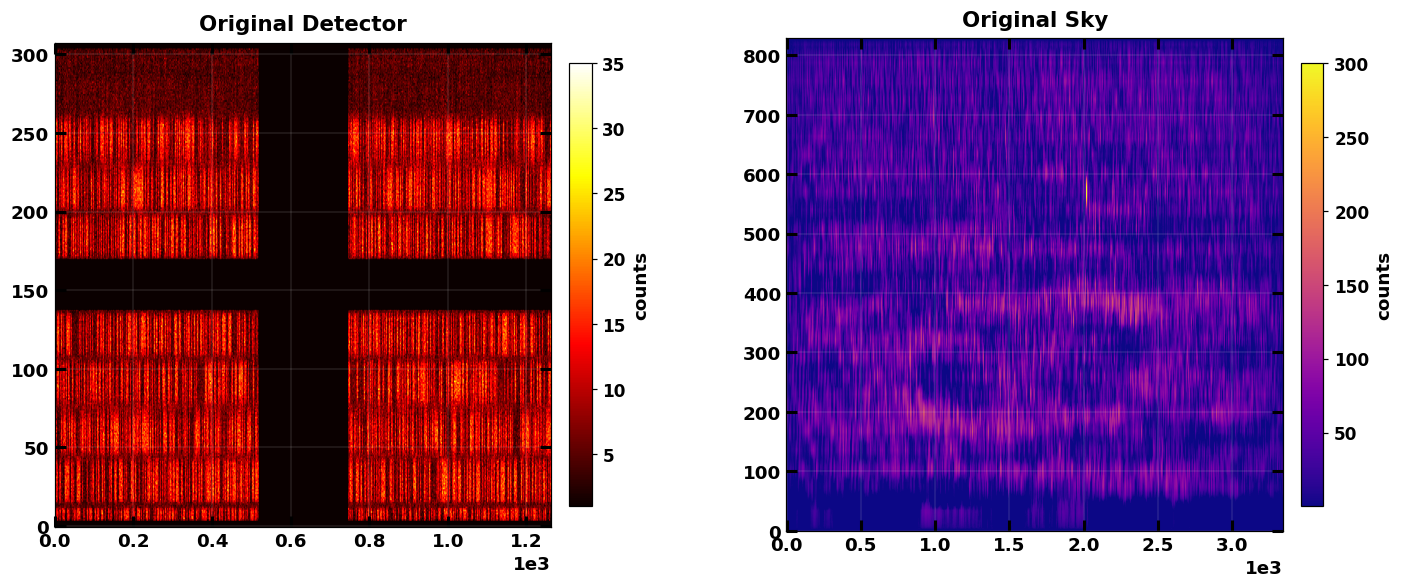

In [ ]:
detector = count(wfm, sdlA.DLdata)[0]


EXP = 0.5
sky_vmax = 3e2

ds.image_plot(
    dmaps=(
        ds.map4image(
            img=detector,
            title='Original Detector',
            cbarlabel='counts',
            img_kwargs={
                'cmap': 'hot',
                'vmin': np.unique(detector)[1],
                'aspect': ASPECT,
            },
        ),
        ds.map4image(
            img=sqrt_display(true_sky_camA, EXP),
            title='Original Sky',
            cbarlabel='counts',
            img_kwargs={
                'cmap': 'plasma',
                'vmax': sky_vmax,
                'aspect': ASPECT,
            },
        ),
    ),
    ncols=2,
)

In [ ]:
# get residual detector image
retrieved = retrieve_detector(
    candidates=candidates,
    camera=wfm,
    vignetting=VIGNETTING,
    psfy=PSFY,
)
resdet = detector - retrieved
res_sky = decode(wfm, resdet)

# perform smoothing on residual detector image
KERNEL_SIZE = {
    'y': 11,
    'x': 7,
}
res_smoothed = ds.bkg_smoothing(
    detector=resdet,
    camera=wfm,
    kernelsize_y=KERNEL_SIZE['y'],
    kernelsize_x=KERNEL_SIZE['x'],
)
res_smooth_sky = decode(wfm, res_smoothed)

# get smoothed detector image
smoothed = detector - res_smoothed
smoothed_sky = decode(wfm, smoothed)

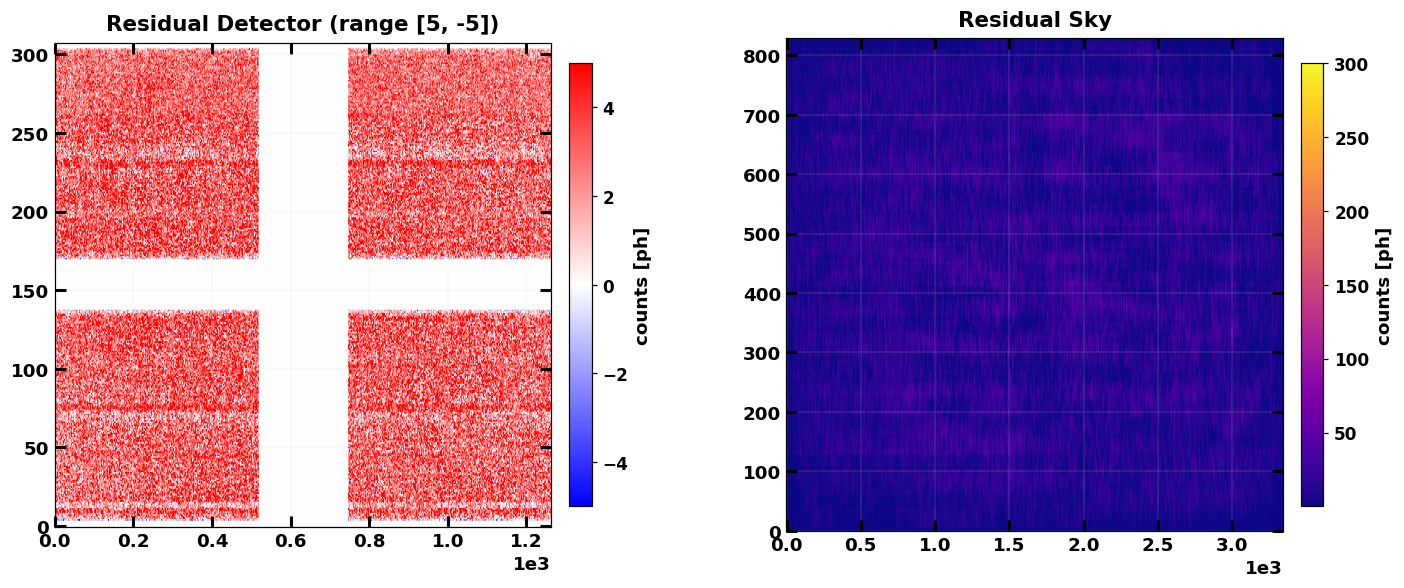

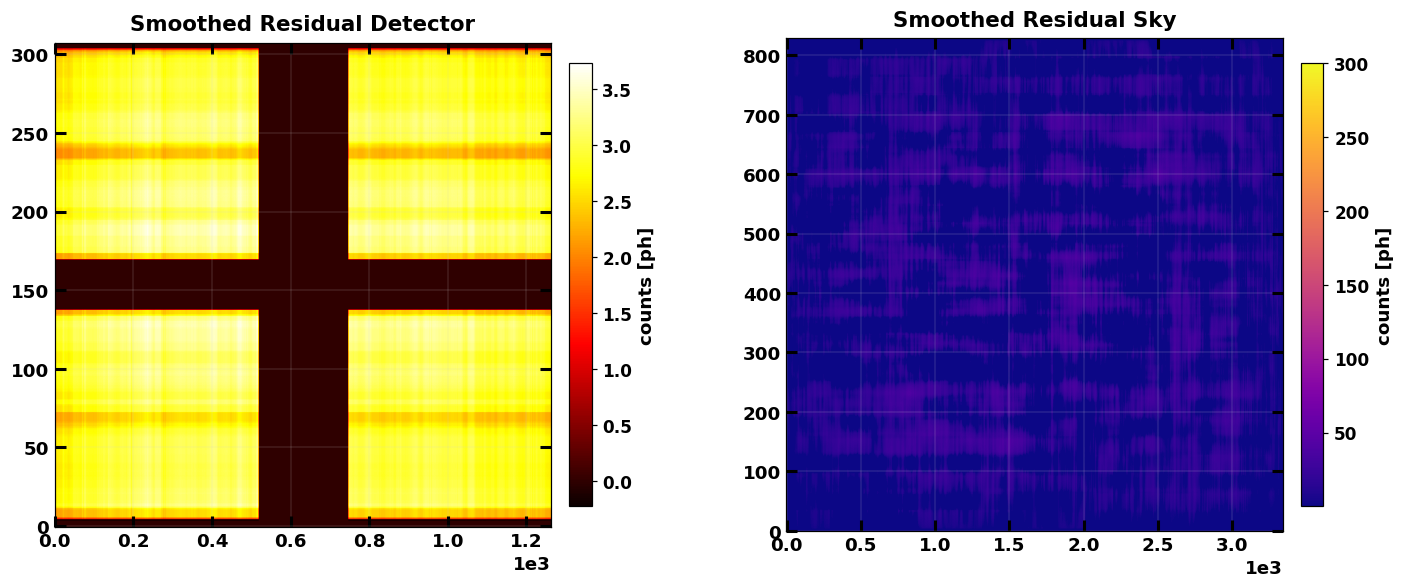

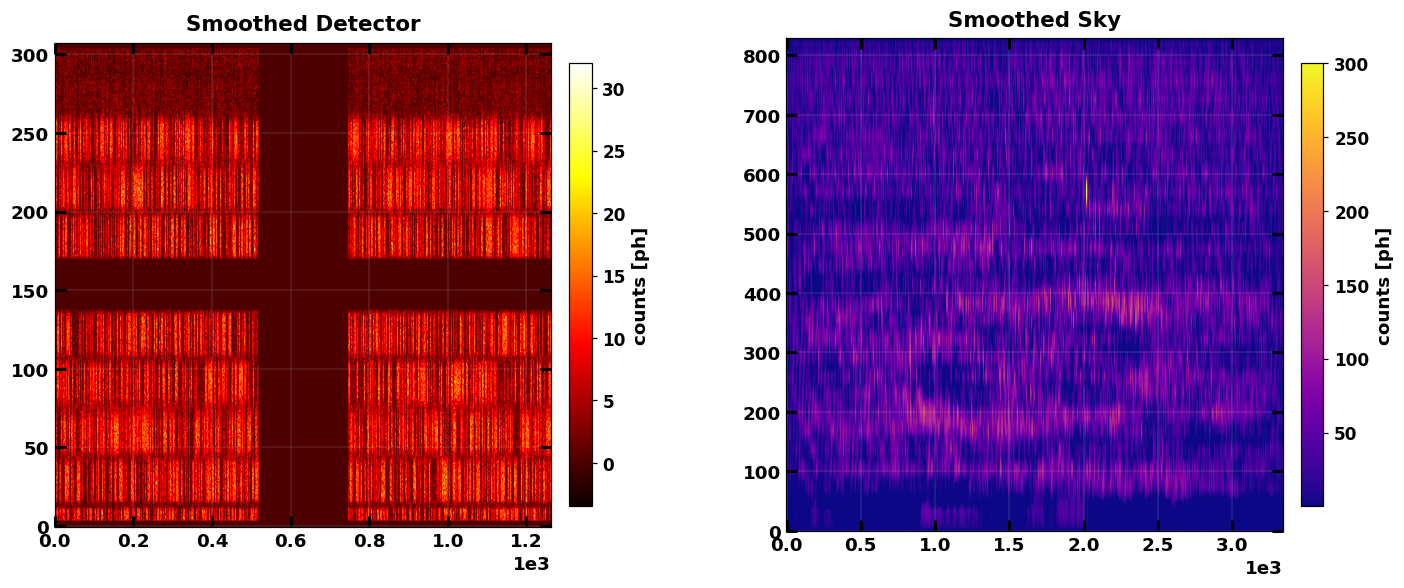

In [ ]:
# plot residual detector and sky
LIM = 5
ds.image_plot(
    dmaps=(
        ds.map4image(
            img=resdet,
            title='Residual Detector' + (f' (range [{LIM}, -{LIM}])' if LIM else ''),
            cbarlabel='counts [ph]',
            img_kwargs={
                'cmap': 'bwr',
                'vmax': LIM if LIM else None,
                'vmin': -LIM if LIM else None,
                'aspect': ASPECT,
            },
        ),
        ds.map4image(
            img=sqrt_display(res_sky, EXP),
            title='Residual Sky',
            cbarlabel='counts [ph]',
            img_kwargs={
                'cmap': 'plasma',
                'vmax': sky_vmax,
                'aspect': ASPECT,
            },
        ),
    ),
    ncols=2,
)

# plot smoothed residual detector and sky
LIM = 0
ds.image_plot(
    dmaps=(
        ds.map4image(
            img=res_smoothed,
            title='Smoothed Residual Detector' + (f' (range [{LIM}, -{LIM}])' if LIM else ''),
            cbarlabel='counts [ph]',
            img_kwargs={
                'cmap': 'hot',
                'vmax': LIM if LIM else None,
                'vmin': -LIM if LIM else None,
                'aspect': ASPECT,
            },
        ),
        ds.map4image(
            img=sqrt_display(res_smooth_sky, EXP),
            title='Smoothed Residual Sky',
            cbarlabel='counts [ph]',
            img_kwargs={
                'cmap': 'plasma',
                'vmax': sky_vmax,
                'aspect': ASPECT,
            },
        ),
    ),
    ncols=2,
)

# plot smoothed original detector and sky
LIM = 0
ds.image_plot(
    dmaps=(
        ds.map4image(
            img=smoothed,
            title='Smoothed Detector' + (f' (range [{LIM}, -{LIM}])' if LIM else ''),
            cbarlabel='counts [ph]',
            img_kwargs={
                'cmap': 'hot',
                'vmax': LIM if LIM else None,
                'vmin': -LIM if LIM else None,
                'aspect': ASPECT,
            },
        ),
        ds.map4image(
            img=sqrt_display(smoothed_sky, EXP),
            title='Smoothed Sky',
            cbarlabel='counts [ph]',
            img_kwargs={
                'cmap': 'plasma',
                'vmax': sky_vmax,
                'aspect': ASPECT,
            },
        ),
    ),
    ncols=2,
)

In [ ]:
# profiles along X and Y axes
collapsed_det_x, collapsed_resdet_x, collapsed_res_smoothed_x, collapsed_smoothed_x = map(
    lambda x: np.sum(x, axis=0),
    (detector, resdet, res_smoothed, smoothed),
)

collapsed_det_y, collapsed_resdet_y, collapsed_res_smoothed_y, collapsed_smoothed_y = map(
    lambda x: np.sum(x, axis=1),
    (detector, resdet, res_smoothed, smoothed),
)

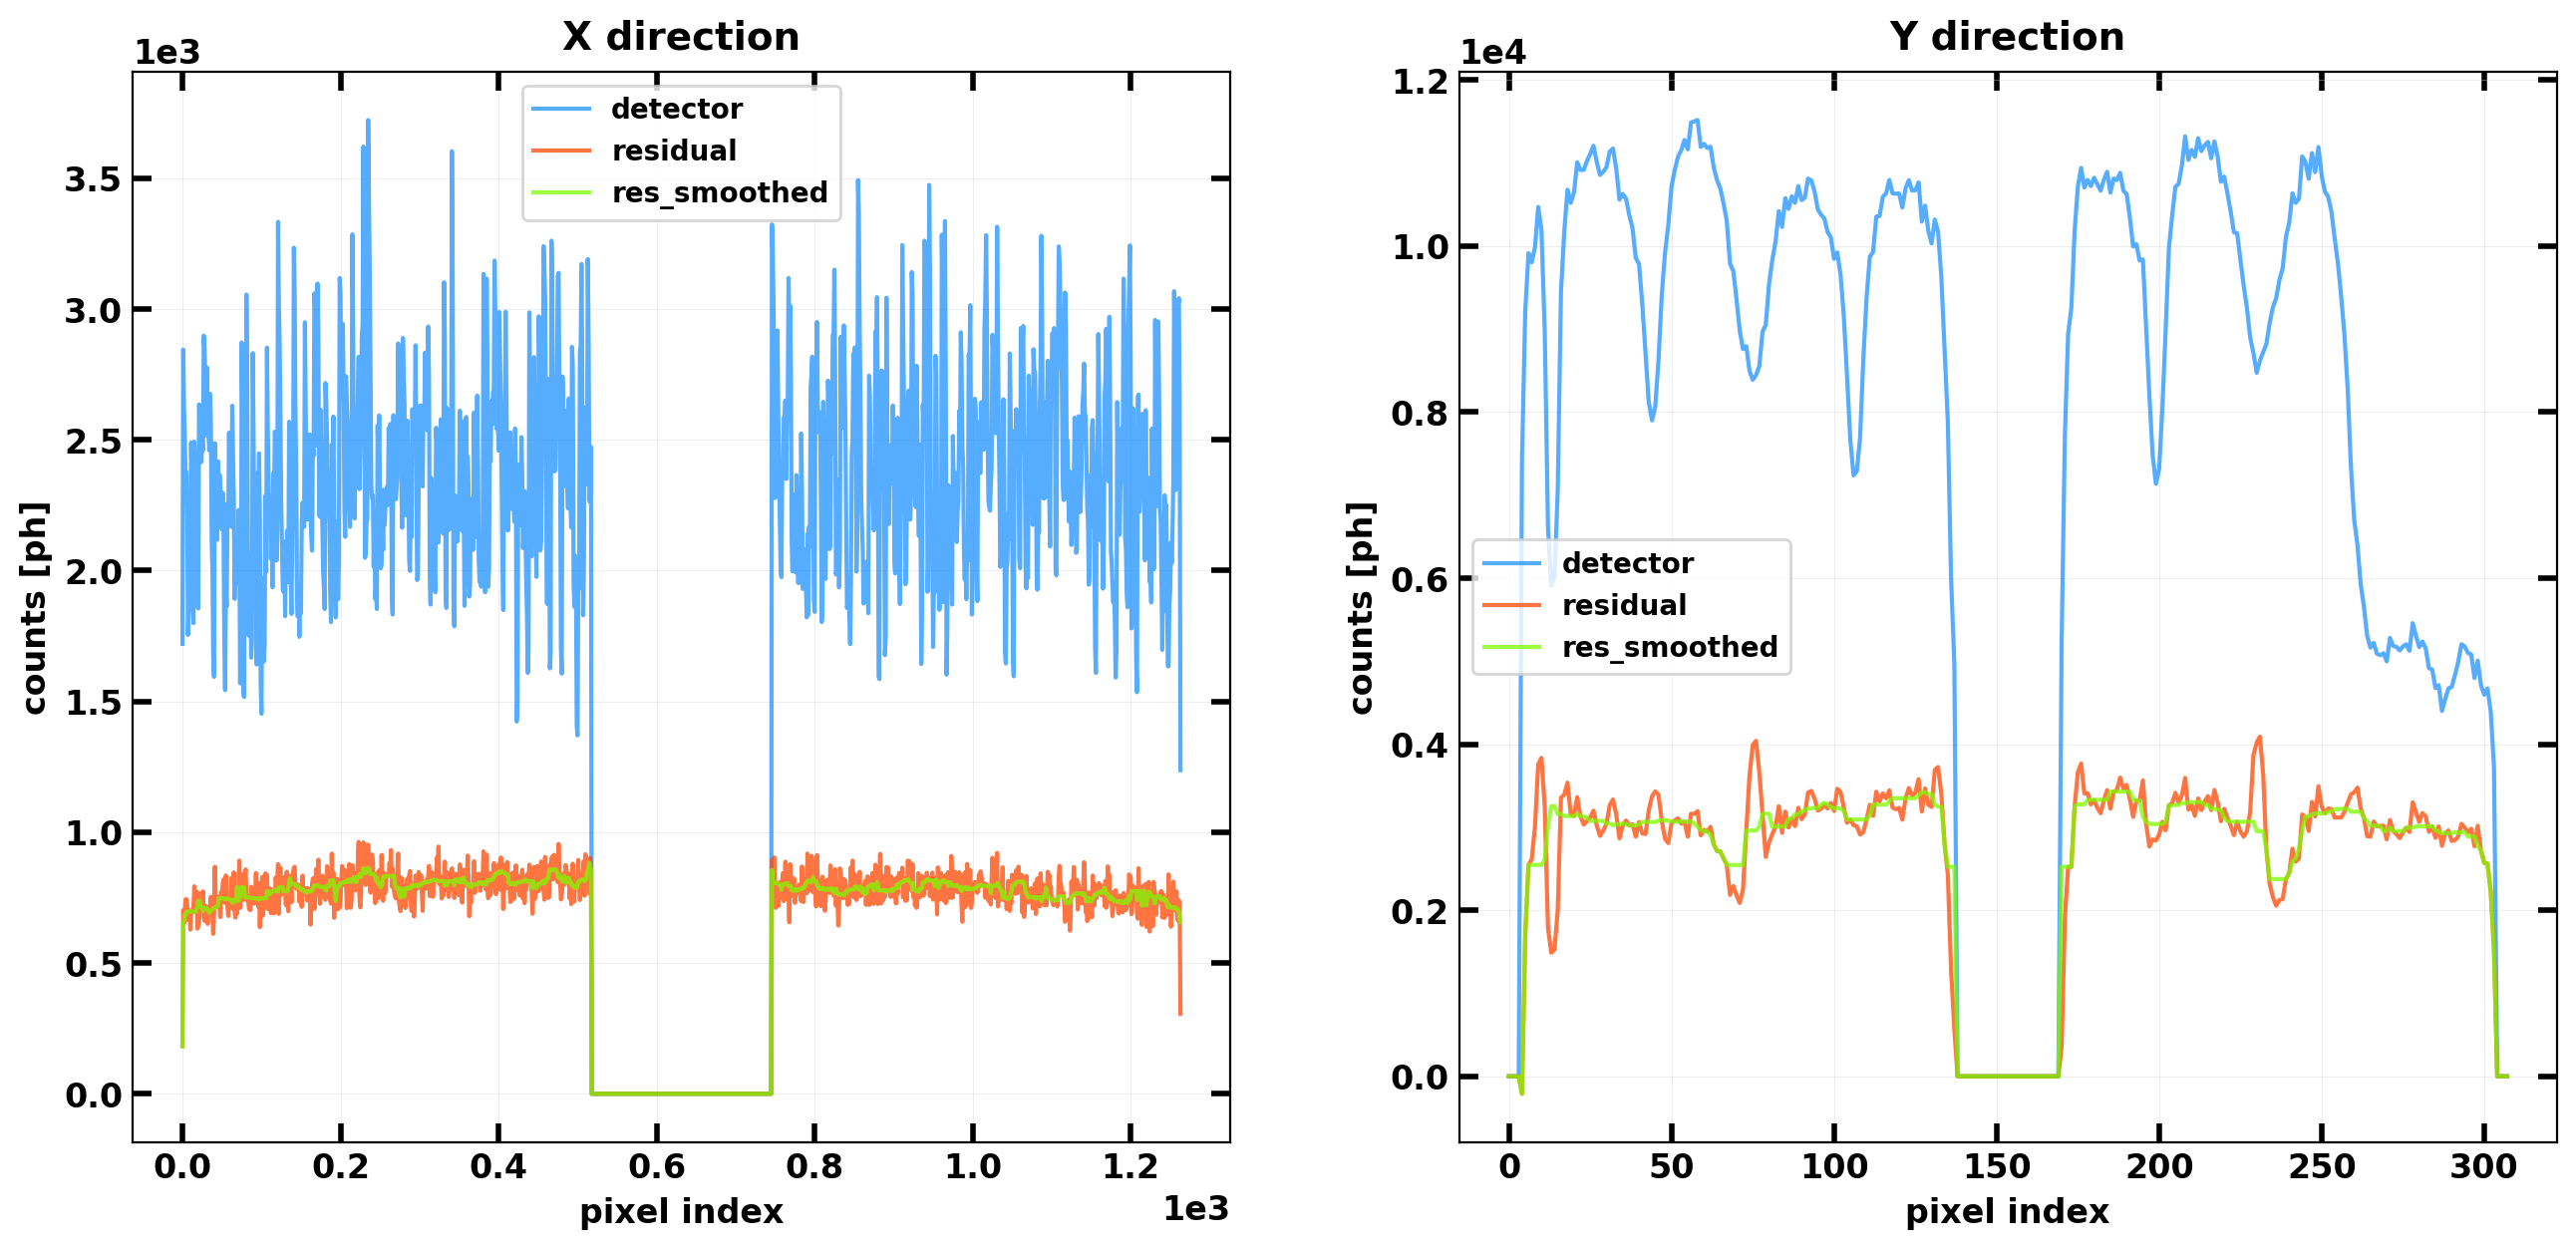

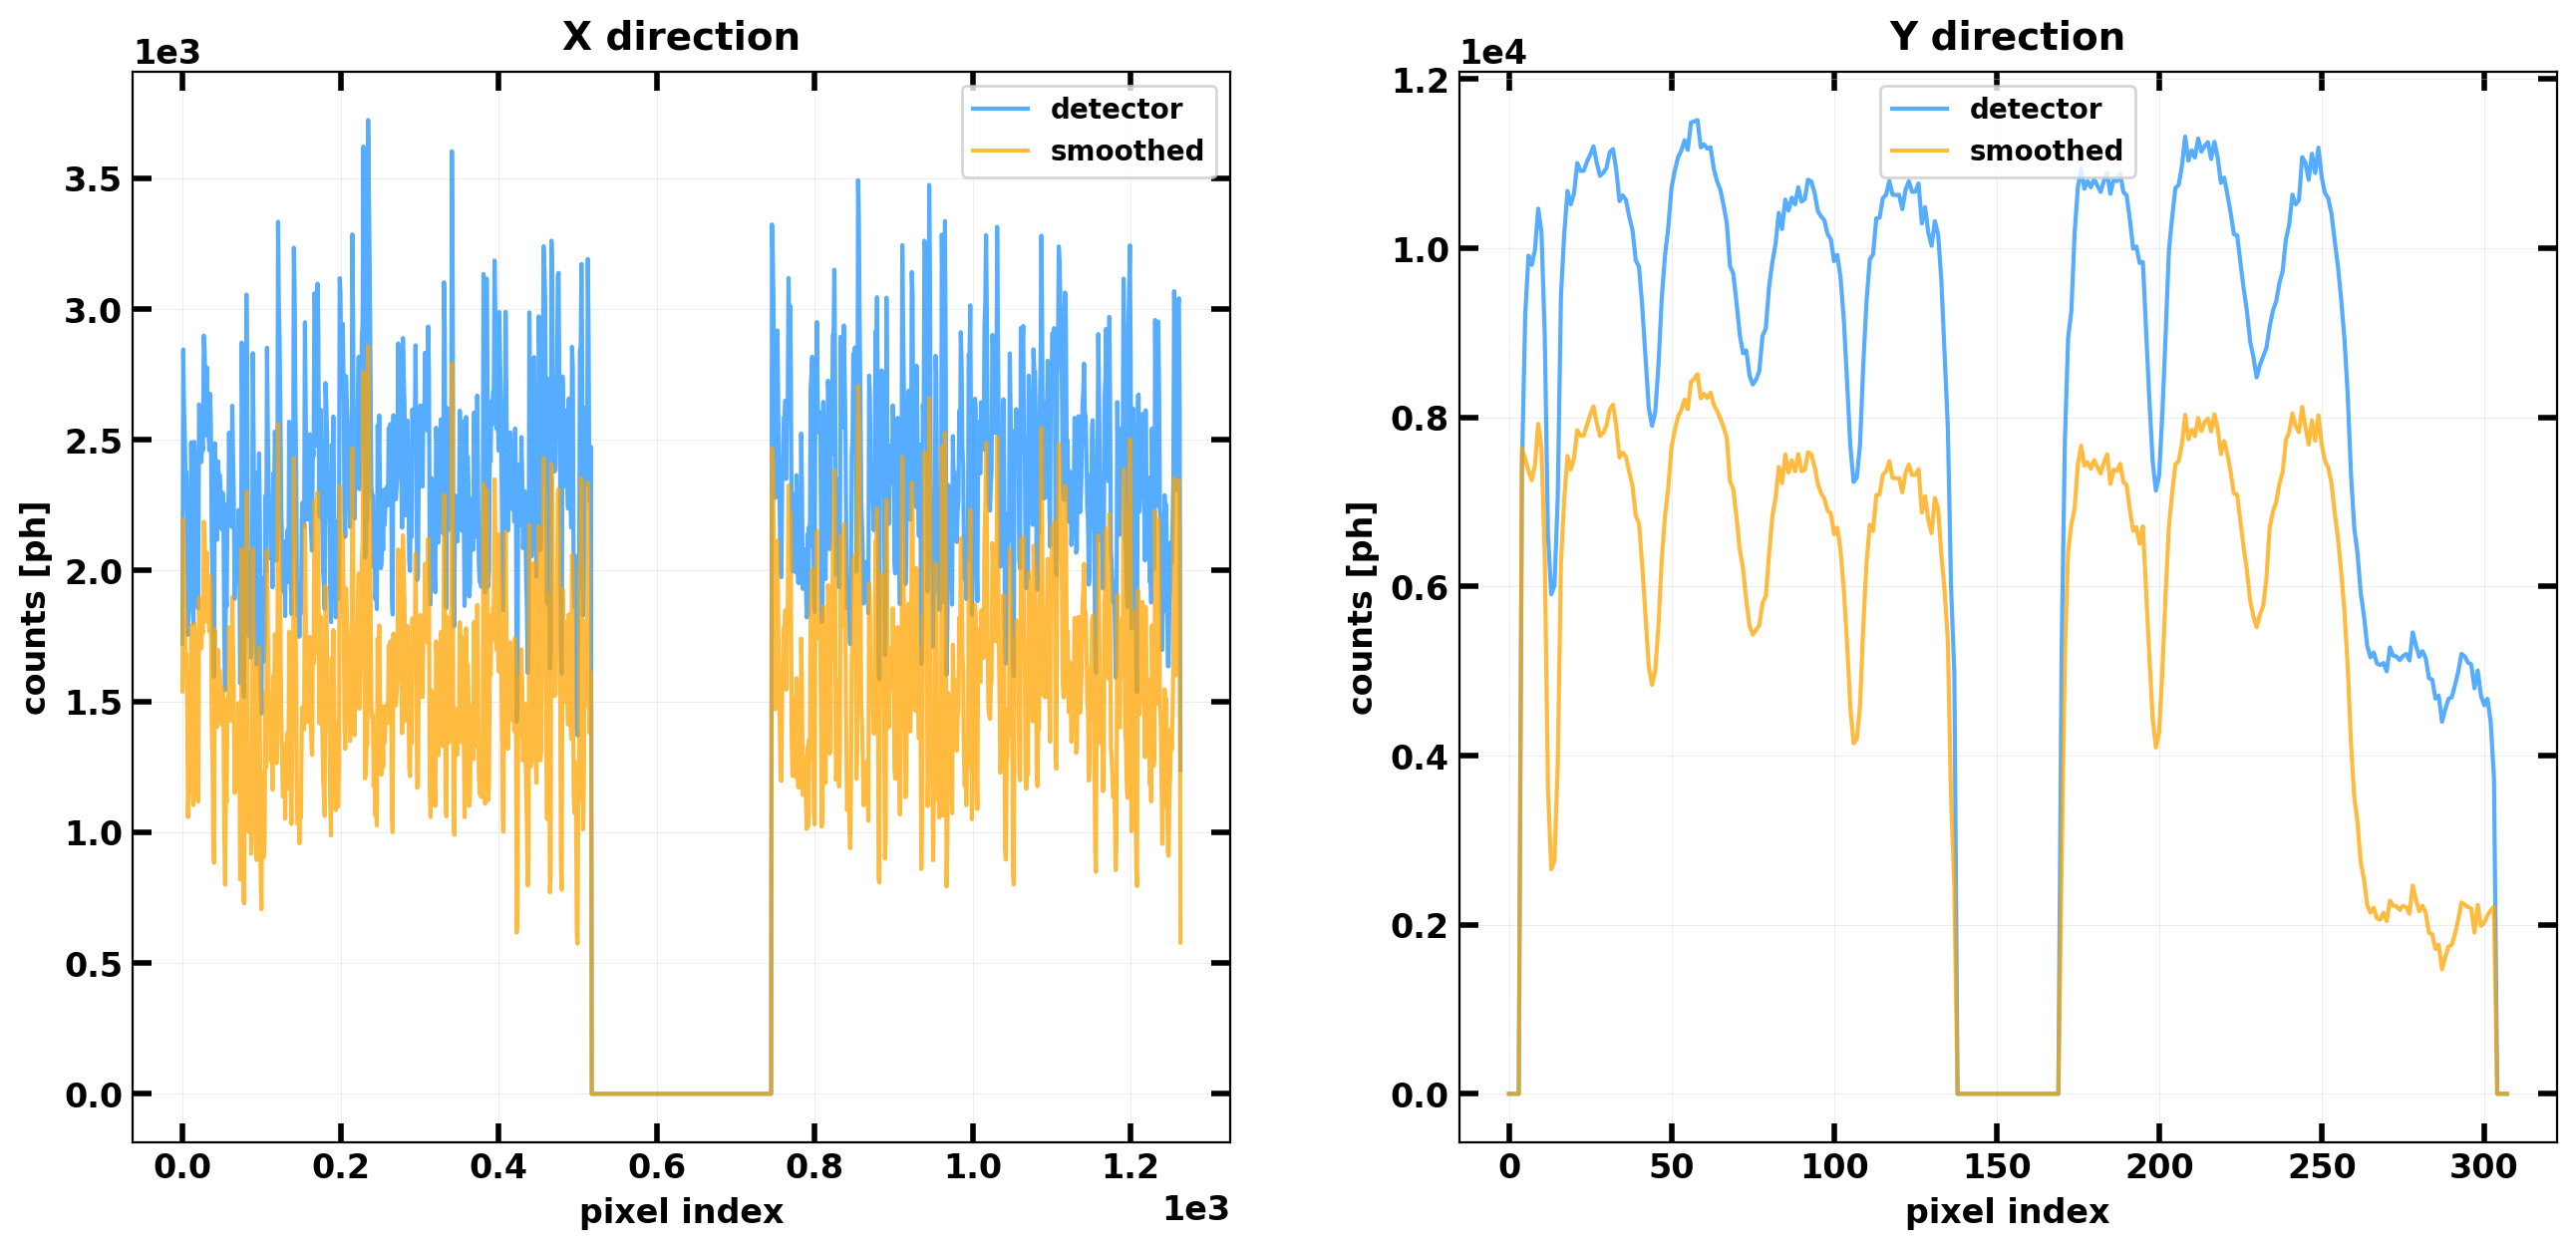

In [ ]:
# plot detectors profiles
dmapx = ds.map4plot(
    arrs=(
        collapsed_det_x, collapsed_resdet_x,
        collapsed_res_smoothed_x,
    ),
    title='X direction',
    ylabel='counts [ph]',
    xlabel='pixel index',
    labels=('detector', 'residual', 'res_smoothed'),
    color=('DodgerBlue', 'OrangeRed', 'LawnGreen'),
)
dmapy = ds.map4plot(
    arrs=(
        collapsed_det_y, collapsed_resdet_y,
        collapsed_res_smoothed_y,
    ),
    title='Y direction',
    ylabel='counts [ph]',
    xlabel='pixel index',
    labels=('detector', 'residual', 'res_smoothed'),
    color=('DodgerBlue', 'OrangeRed', 'LawnGreen'),
)
ds.plot(dmaps=(dmapx, dmapy), ncols=2)

dmapx_cfr = ds.map4plot(
    arrs=(
        collapsed_det_x, collapsed_smoothed_x,
    ),
    title='X direction',
    ylabel='counts [ph]',
    xlabel='pixel index',
    labels=('detector', 'smoothed'),
    color=('DodgerBlue', 'Orange'),
)
dmapy_cfr = ds.map4plot(
    arrs=(
        collapsed_det_y, collapsed_smoothed_y,
    ),
    title='Y direction',
    ylabel='counts [ph]',
    xlabel='pixel index',
    labels=('detector', 'smoothed'),
    color=('DodgerBlue', 'Orange'),
)
ds.plot(dmaps=(dmapx_cfr, dmapy_cfr), ncols=2)

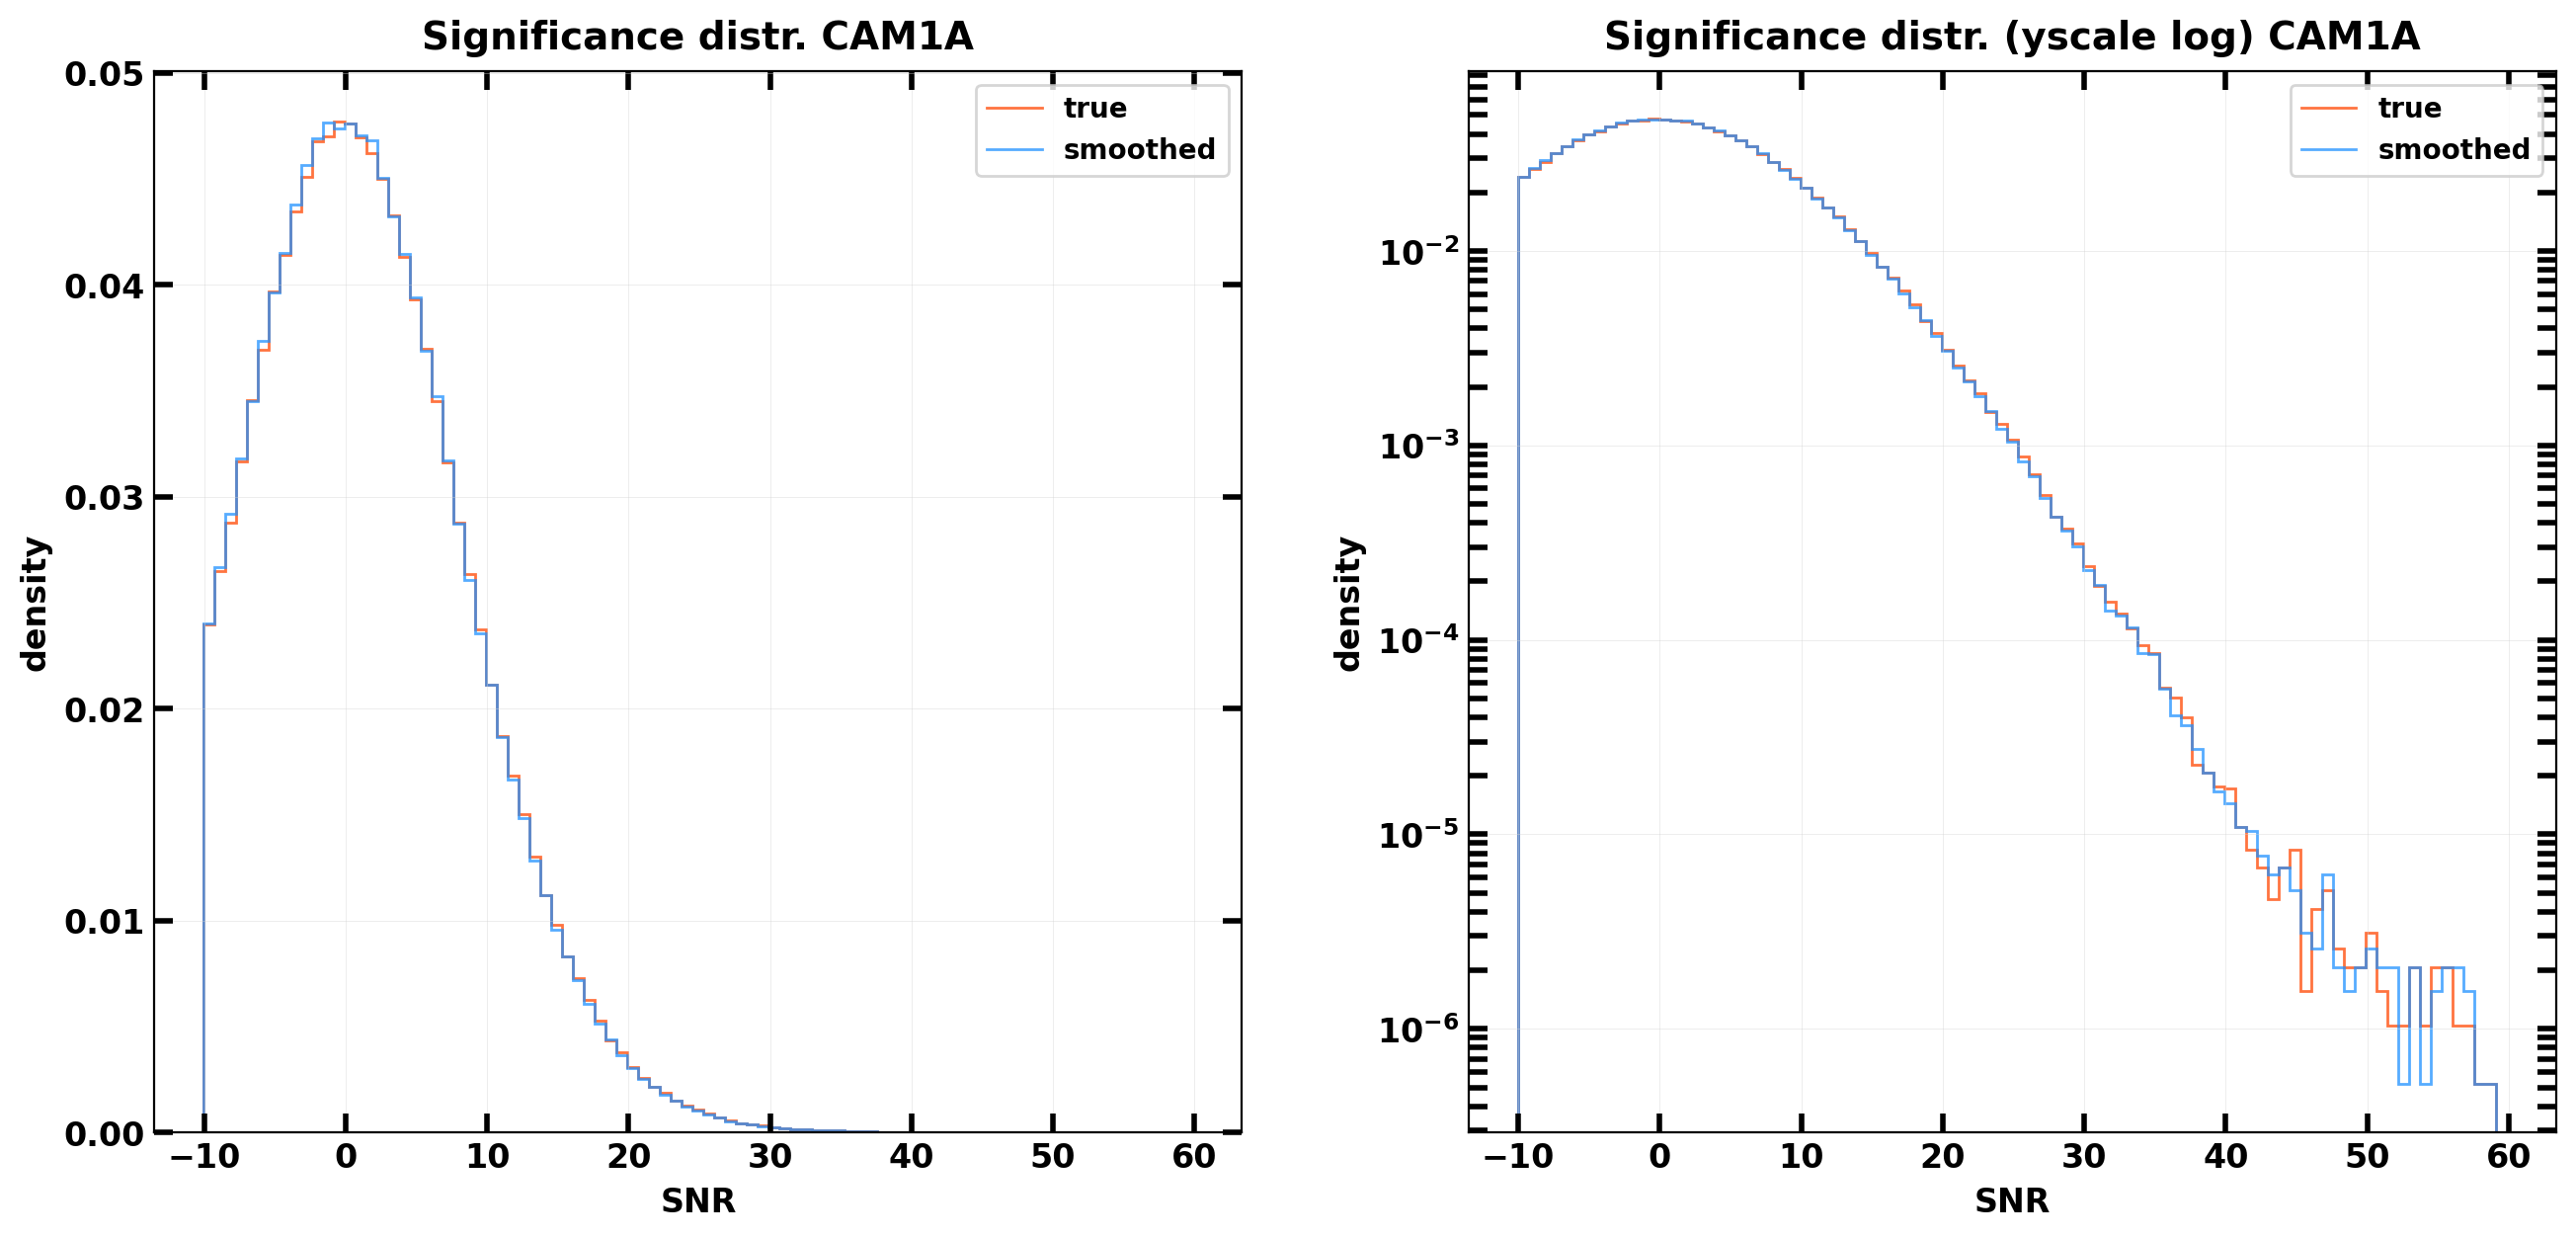

In [ ]:
# sky significance distr. for true detector and smoothed detector
varmap = variance(wfm, detector)

ycut, xcut = UPS_Y * 30, UPS_X * 20
true_skysnr_camA = ds.unframe(snratio(true_sky_camA, varmap), ycut, xcut)
smoothed_skysnr_camA = ds.unframe(snratio(smoothed_sky, varmap), ycut, xcut)

num_bins = 1000
density = True
hist_true_skysnr, bins = np.histogram(true_skysnr_camA, bins=num_bins, density=density)
hist_smoothed_skysnr, _ = np.histogram(smoothed_skysnr_camA, bins=bins, density=density)


x0, xN = -10, 60
bins_slice, hist_slice = config_snrlim(bins, x0, xN)

dmap1_snr = ds.map4plot(
    arrs=(hist_true_skysnr[hist_slice], hist_smoothed_skysnr[hist_slice]),
    title=f'Significance distr. {ID_CAMERA_A.upper()}',
    xlabel='SNR',
    ylabel='density',
    labels=('true', 'smoothed'),
    x=bins[bins_slice],
    style='stairs',
    color=('OrangeRed', 'Dodgerblue'),
)
dmap2_snr = ds.map4plot(
    arrs=(hist_true_skysnr[hist_slice], hist_smoothed_skysnr[hist_slice]),
    title=f'Significance distr. (yscale log) {ID_CAMERA_A.upper()}',
    xlabel='SNR',
    ylabel='density',
    labels=('true', 'smoothed'),
    x=bins[bins_slice],
    style='stairs',
    color=('OrangeRed', 'Dodgerblue'),
    yscale='log',
)
ds.plot(
    dmaps=(dmap1_snr, dmap2_snr),
    ncols=2,
    save_to=(
        savefig_to(SAVE_TO, f'CFR_snr_distr_{ID_CAMERA_A.upper()}')
        if SAVE_THINGS else None
    ),
)

In [ ]:
smooth_analysis_ID = f'{ANALYSIS_ID}_smoothing'
smooth_save_path = f'{save_path}../{smooth_analysis_ID}/'
log_camA_smoothed, _ = ds.load_database(smooth_save_path + f"IROS_sources_database_TEST_{smooth_analysis_ID}.fits")

smoothed_candidates = get_candidates(log_camA_smoothed, SMOOTHING_THRESHOLD)

# Loading data...
# Loading completed!
Number of candidates with SNR > 15.0: 12
Last: gx9+9 (snr = 16.25)
Following: x1735-444 (snr = 12.13)



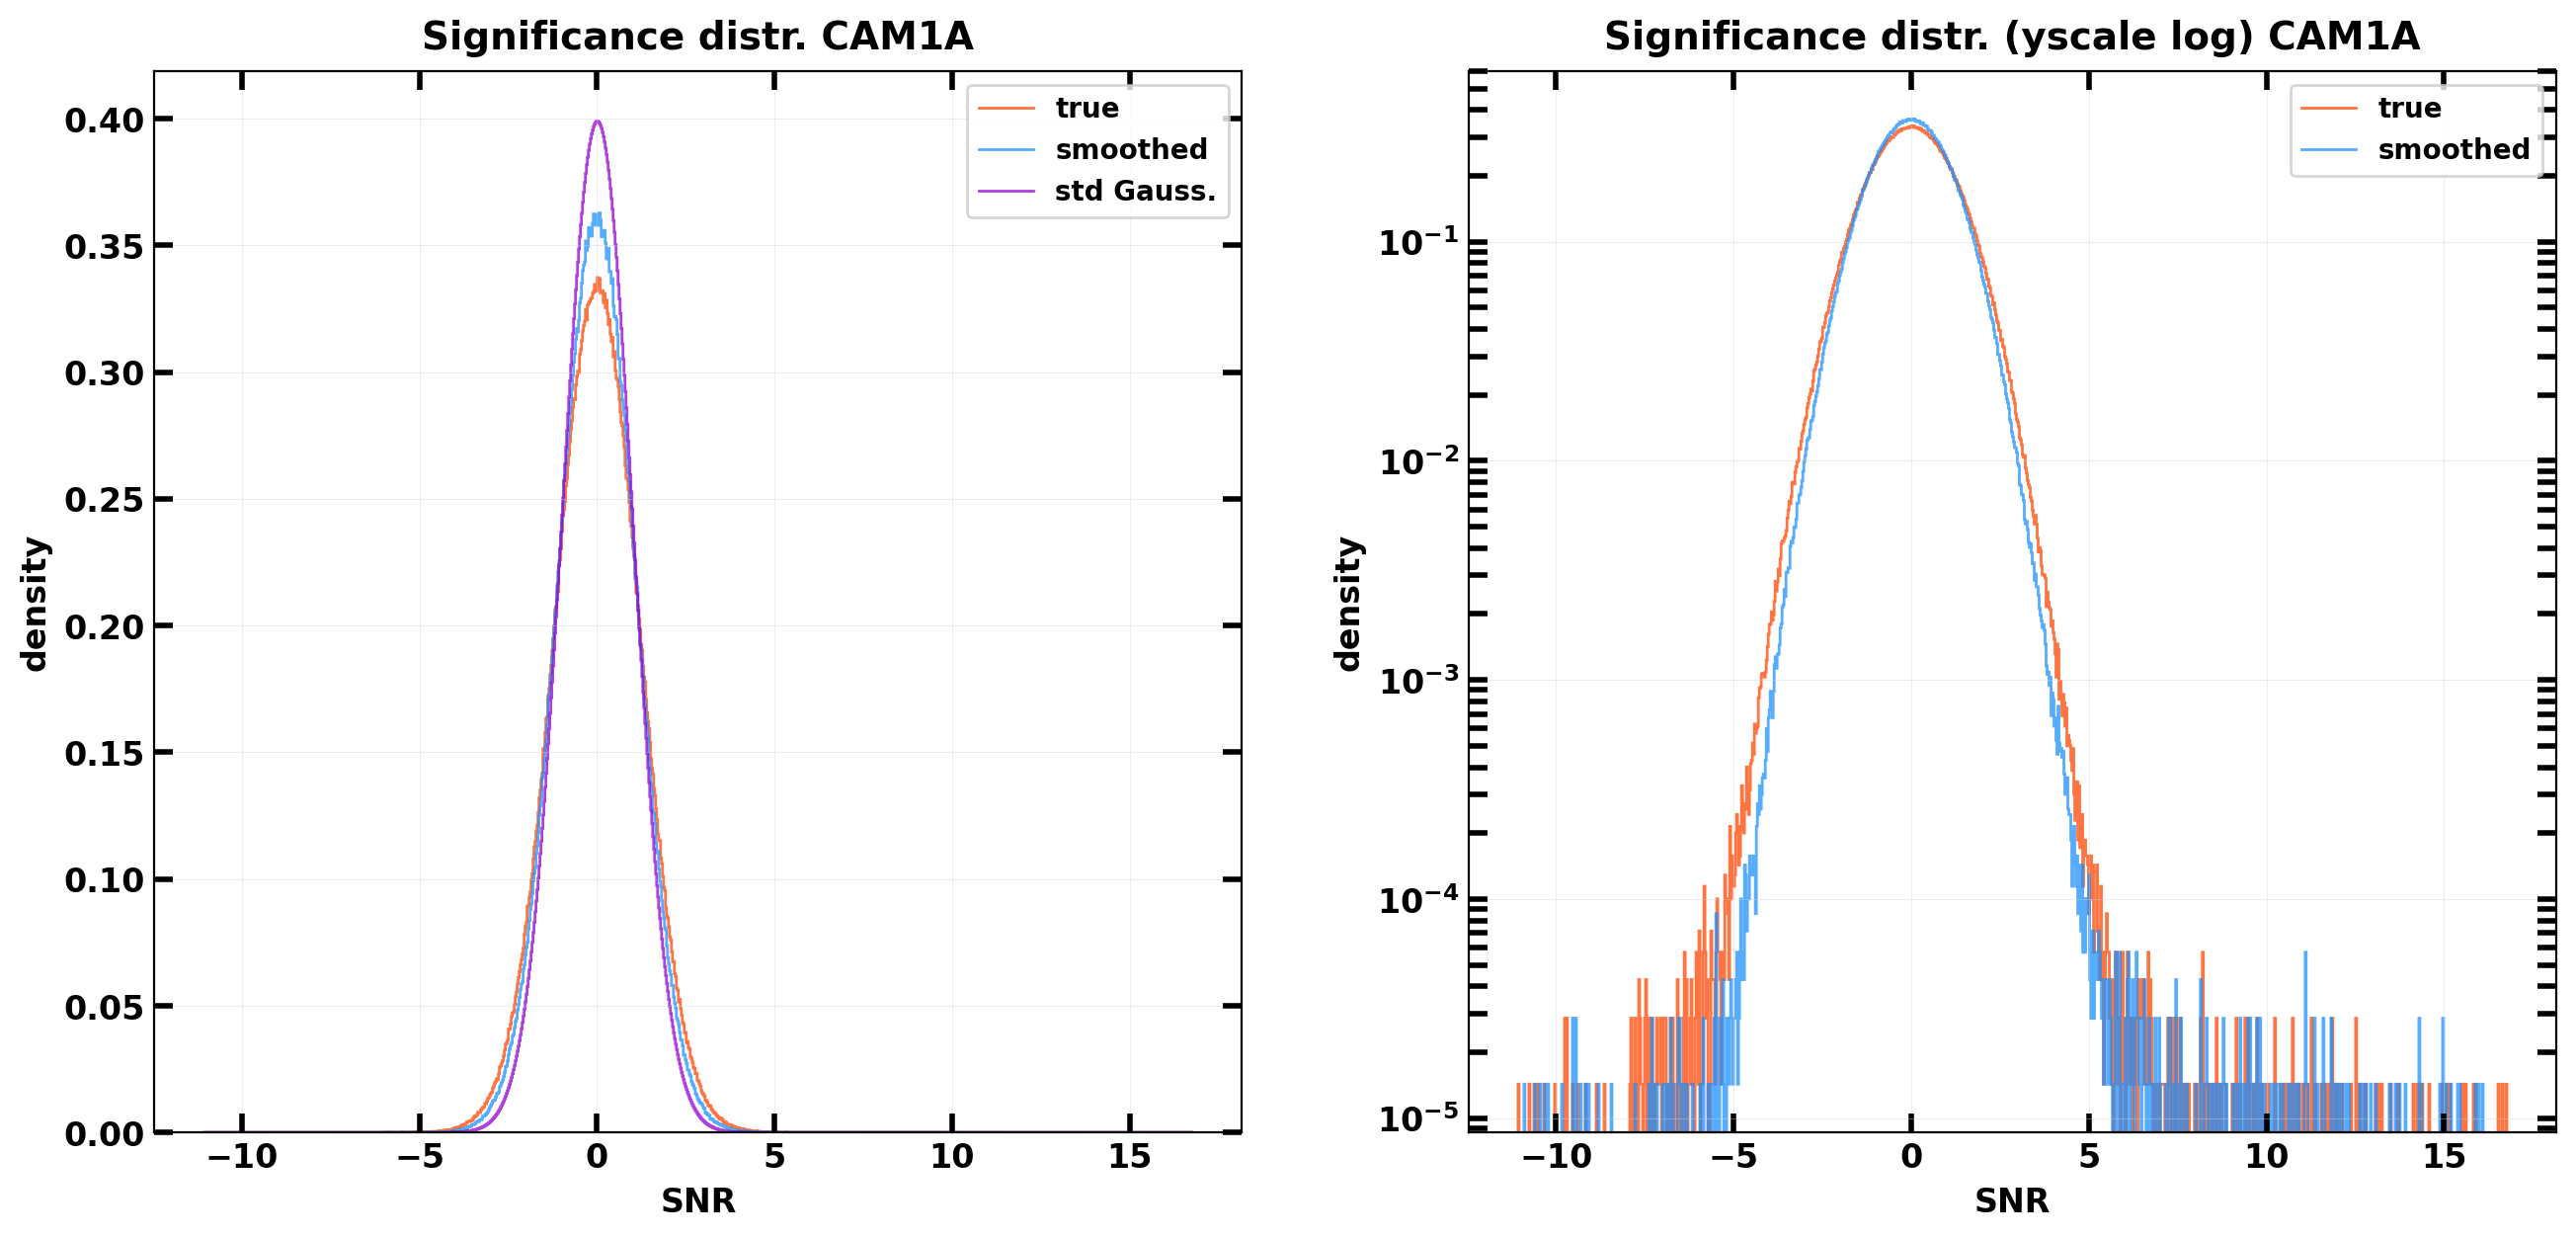

In [ ]:
smoothed_retrieved = retrieve_detector(
    candidates=smoothed_candidates,
    camera=wfm,
    vignetting=VIGNETTING,
    psfy=PSFY,
)
res_detector = smoothed - smoothed_retrieved
res_smoothed_sky = decode(wfm, res_detector)

res_skysnr_camA = ds.unframe(snratio(res_sky, varmap), ycut, xcut)
smoothed_skysnr_camA = ds.unframe(snratio(res_smoothed_sky, varmap), ycut, xcut)

hist_res_skysnr, bins = np.histogram(res_skysnr_camA, bins=num_bins, density=density)
hist_res_smoothed_skysnr, _ = np.histogram(smoothed_skysnr_camA, bins=bins, density=density)

gauss_distr = Gaussian(bins)[:-1]


x0, xN = None, None
bins_slice, hist_slice = config_snrlim(bins, x0, xN)

dmap1_snr = ds.map4plot(
    arrs=(hist_res_skysnr[hist_slice], hist_res_smoothed_skysnr[hist_slice], gauss_distr[hist_slice]),
    title=f'Significance distr. {ID_CAMERA_A.upper()}',
    xlabel='SNR',
    ylabel='density',
    labels=('true', 'smoothed', 'std Gauss.'),
    x=bins[bins_slice],
    style='stairs',
    color=('OrangeRed', 'Dodgerblue', 'DarkViolet'),
)
dmap2_snr = ds.map4plot(
    arrs=(hist_res_skysnr[hist_slice], hist_res_smoothed_skysnr[hist_slice]),
    title=f'Significance distr. (yscale log) {ID_CAMERA_A.upper()}',
    xlabel='SNR',
    ylabel='density',
    labels=('true', 'smoothed', 'std Gauss.'),
    x=bins[bins_slice],
    style='stairs',
    color=('OrangeRed', 'Dodgerblue'),
    yscale='log',
)
ds.plot(
    dmaps=(dmap1_snr, dmap2_snr),
    ncols=2,
    save_to=(
        savefig_to(SAVE_TO, f'CFR_snr_distr_{ID_CAMERA_A.upper()}')
        if SAVE_THINGS else None
    ),
)

In [ ]:
from scipy.optimize import curve_fit

center_bins = 0.5 * (bins[:-1] + bins[1:])

popt_original, _ = curve_fit(Gaussian, xdata=center_bins, ydata=hist_res_skysnr, p0=[0, 1.0])
popt_smooothed, _ = curve_fit(Gaussian, xdata=center_bins, ydata=hist_res_smoothed_skysnr, p0=[0, 1.0])

print('Original (mu, sigma):', *popt_original)
print('Smoothed (mu, sigma):', *popt_smooothed)

Original (mu, sigma): 0.006806630541802794 1.1984689786652658
Smoothed (mu, sigma): -0.0006968464776918237 1.1093346400145785


In [ ]:
# sources data + angular coords residues plot
data_DF(
    log=log_camA,
    catalogue=catalogueA,
    sdl=sdlA,
    camera=wfm,
)

Pixel angular resolution at upscaling (x, y): 2, 1
  - fine direction: 2.1163 arcmin
  - coarse direction: 8.4653 arcmin

# Source: scox1
Selected 1103435 ph out of 2564475 ph.
# Source: gx5-1
Selected 123492 ph out of 2564475 ph.
# Source: gx349+2
Selected 89697 ph out of 2564475 ph.
# Source: gx17+2
Selected 78613 ph out of 2564475 ph.
# Source: gx9+1
Selected 68158 ph out of 2564475 ph.
# Source: gx340+0
Selected 51095 ph out of 2564475 ph.
# Source: groj1655-40
Selected 44765 ph out of 2564475 ph.
# Source: gx13+1
Selected 38603 ph out of 2564475 ph.
# Source: x1820-303
Selected 38618 ph out of 2564475 ph.
# Source: gx3+1
Selected 38505 ph out of 2564475 ph.
# Source: cirx1
Selected 27385 ph out of 2564475 ph.
# Source: gx9+9
Selected 34075 ph out of 2564475 ph.
# Source: x1735-444
Selected 20956 ph out of 2564475 ph.
# Source: x1705-440
Selected 20644 ph out of 2564475 ph.
# Source: grs1915+105
Selected 10612 ph out of 2564475 ph.
# Source: gx354-0
Selected 12541 ph out of 2564475

CAM1A                                                           
                ID         SNR DthetaX [arcmin] DthetaY [arcmin] Dfluence [%]
0            scox1  718.749706         0.023809         0.040658    -1.185980
1            gx5-1   70.508029         0.087865         1.335412    -3.047770
2          gx349+2   49.093451         0.098277         1.452365    -4.176541
3           gx17+2   39.793000         0.626402         5.079425    -9.017117
4            gx9+1   38.630481         0.081705         0.746797     0.083068
5          gx340+0   31.256652         0.120740         2.334580    -4.098886
6      groj1655-40   27.398383         0.080895         5.708893     2.278252
7           gx13+1   23.668396         0.158052         7.387733     5.011599
8        x1820-303   23.661893         0.306326         7.326923     3.320168
9            gx3+1   20.131140         0.105579        11.954682    -2.422596
10           cirx1   28.349602         0.054930         0.738529    10.632201
11           gx9+9   15.775716         0.186264         9.455781   -10.648204
12       x1735-444   12.766580         0.088718        36.341051    -3.571040
13       x1705-440   12.149027         0.125373        15.954224   -10.549192
14     grs1915+105   16.823627         0.094900         6.386439    -2.156250
15         gx354-0    6.120330         0.465630        20.323787    -7.639156
16  igrj17098-3626    5.255781         2.751260         3.353819   360.655323

In [ ]:
data_DF(
    log=log_camA_smoothed,
    catalogue=catalogueA,
    sdl=sdlA,
    camera=wfm,
)

Pixel angular resolution at upscaling (x, y): 2, 1
  - fine direction: 2.1163 arcmin
  - coarse direction: 8.4653 arcmin

# Source: scox1
Selected 1103435 ph out of 2564475 ph.
# Source: gx5-1
Selected 123492 ph out of 2564475 ph.
# Source: gx349+2
Selected 89697 ph out of 2564475 ph.
# Source: gx17+2
Selected 78613 ph out of 2564475 ph.
# Source: gx9+1
Selected 68158 ph out of 2564475 ph.
# Source: gx340+0
Selected 51095 ph out of 2564475 ph.
# Source: groj1655-40
Selected 44765 ph out of 2564475 ph.
# Source: x1820-303
Selected 38618 ph out of 2564475 ph.
# Source: gx13+1
Selected 38603 ph out of 2564475 ph.
# Source: gx3+1
Selected 38505 ph out of 2564475 ph.
# Source: cirx1
Selected 27385 ph out of 2564475 ph.
# Source: gx9+9
Selected 34075 ph out of 2564475 ph.
# Source: x1735-444
Selected 20956 ph out of 2564475 ph.
# Source: x1705-440
Selected 20644 ph out of 2564475 ph.
# Source: grs1915+105
Selected 10612 ph out of 2564475 ph.
# Source: igrj17098-3626
Selected 1768 ph out of 2

CAM1A                                                           
                ID         SNR DthetaX [arcmin] DthetaY [arcmin] Dfluence [%]
0            scox1  719.268066         0.026226         0.102160    -1.093606
1            gx5-1   70.744119         0.081125         1.349316    -2.732959
2          gx349+2   49.461878         0.099417         1.542169    -2.893393
3           gx17+2   40.238821         0.626402         5.079425    -7.997789
4            gx9+1   37.641437         0.089641         0.437093    -4.064267
5          gx340+0   31.809629         0.119503         1.110861    -1.773775
6      groj1655-40   28.107799         0.092634         6.403348     5.531571
7        x1820-303   24.705554         0.338102         4.806172     8.523819
8           gx13+1   23.484267         0.080255         0.146355     3.732713
9            gx3+1   20.553210         0.146186        10.956129     0.835017
10           cirx1   28.204348         0.042178         5.420073     9.251531
11           gx9+9   16.252834         0.179089        10.006653    -7.945863
12       x1735-444   12.132792         0.115278        36.341051   -11.573545
13       x1705-440   12.045333         0.147262        16.966203   -11.397647
14     grs1915+105   16.859807         0.030308         7.933796     3.157372
15  igrj17098-3626    5.813474         2.873577         0.162636   408.890470
16         gx354-0    5.553985         0.502071        14.993565   -19.460985

In [ ]:
## smoothing
#   - clip starting detector

## catalogue data
#   - write general method for catalogue source data extraction (e.g., RA/Dec, angular coords, fluences)
#   - write method to filter catalogue data wtr the reconstructed sources (through the Log)
#   - write method for coords and fluences residuals (e.g., RA/Dec, Thetas and fluences*)
#
# * NOTE: to compute the REAL detected photons from catalogue, there's the need for `np.sum(det_image * (camera.bulk > 0))`

**Analysis for LEM-X Camera B**

In [ ]:
assert ANALYSIS_CAM1B

In [ ]:
SMOOTHING_THRESHOLD: int | float = 15.0

candidates: tuple[Candidate, ...] = get_candidates(log_camB, SMOOTHING_THRESHOLD)
detector = count(wfm, sdlB.DLdata)[0]

Number of candidates with SNR > 15.0: 13
Last: x1705-440 (snr = 15.45)
Following: x1735-444 (snr = 12.89)



In [ ]:
# get residual detector image
retrieved = retrieve_detector(
    candidates=candidates,
    camera=wfm,
    vignetting=VIGNETTING,
    psfy=PSFY,
)
resdet = detector - retrieved
res_sky = decode(wfm, resdet)

# perform smoothing on residual detector image
KERNEL_SIZE = {
    'y': 11,
    'x': 7,
}
res_smoothed = ds.bkg_smoothing(
    detector=resdet,
    camera=wfm,
    kernelsize_y=KERNEL_SIZE['y'],
    kernelsize_x=KERNEL_SIZE['x'],
)
res_smooth_sky = decode(wfm, res_smoothed)

# get smoothed detector image
smoothed = detector - res_smoothed
smoothed_sky = decode(wfm, smoothed)

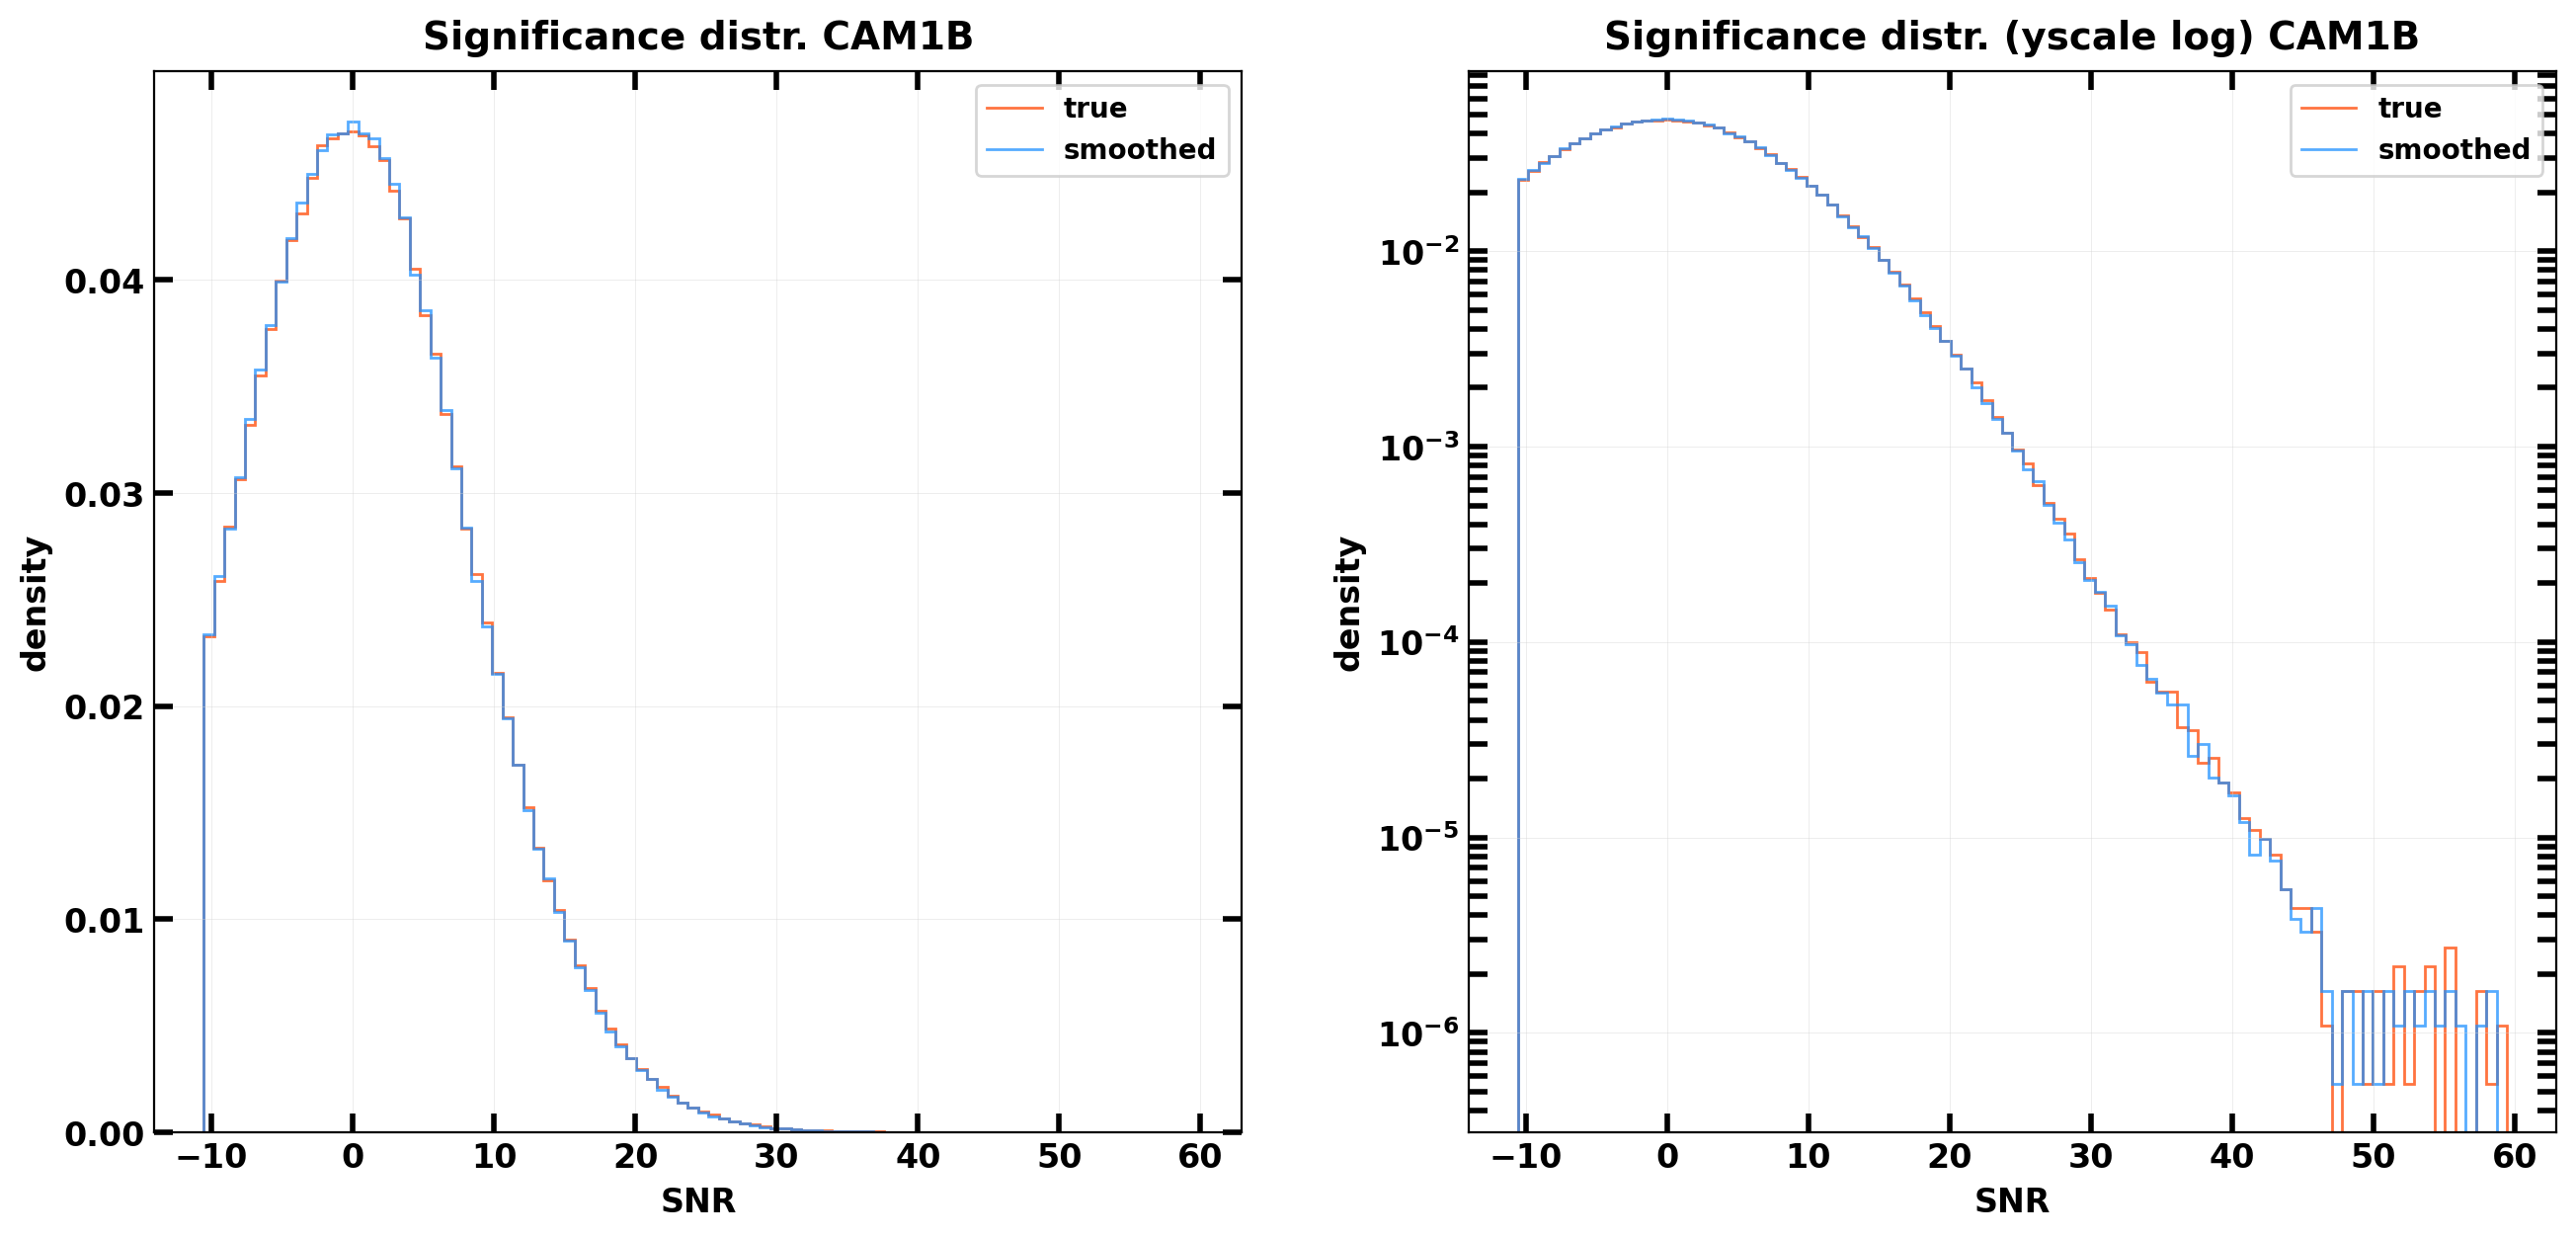

In [ ]:
# sky significance distr. for true detector and smoothed detector
varmap = variance(wfm, detector)

ycut, xcut = UPS_Y * 30, UPS_X * 20
true_skysnr_camB = ds.unframe(snratio(true_sky_camB, varmap), ycut, xcut)
smoothed_skysnr_camB = ds.unframe(snratio(smoothed_sky, varmap), ycut, xcut)

num_bins = 1000
density = True
hist_true_skysnr, bins = np.histogram(true_skysnr_camB, bins=num_bins, density=density)
hist_smoothed_skysnr, _ = np.histogram(smoothed_skysnr_camB, bins=bins, density=density)


x0, xN = -10, 60
bins_slice, hist_slice = config_snrlim(bins, x0, xN)

dmap1_snr = ds.map4plot(
    arrs=(hist_true_skysnr[hist_slice], hist_smoothed_skysnr[hist_slice]),
    title=f'Significance distr. {ID_CAMERA_B.upper()}',
    xlabel='SNR',
    ylabel='density',
    labels=('true', 'smoothed'),
    x=bins[bins_slice],
    style='stairs',
    color=('OrangeRed', 'Dodgerblue'),
)
dmap2_snr = ds.map4plot(
    arrs=(hist_true_skysnr[hist_slice], hist_smoothed_skysnr[hist_slice]),
    title=f'Significance distr. (yscale log) {ID_CAMERA_B.upper()}',
    xlabel='SNR',
    ylabel='density',
    labels=('true', 'smoothed'),
    x=bins[bins_slice],
    style='stairs',
    color=('OrangeRed', 'Dodgerblue'),
    yscale='log',
)
ds.plot(
    dmaps=(dmap1_snr, dmap2_snr),
    ncols=2,
    save_to=(
        savefig_to(SAVE_TO, f'CFR_snr_distr_{ID_CAMERA_B.upper()}')
        if SAVE_THINGS else None
    ),
)

In [ ]:
smooth_analysis_ID = f'{ANALYSIS_ID}_smoothing'
smooth_save_path = f'{save_path}../{smooth_analysis_ID}/'
_, log_camB_smoothed = ds.load_database(smooth_save_path + f"IROS_sources_database_TEST_{smooth_analysis_ID}.fits")

smoothed_candidates = get_candidates(log_camB_smoothed, SMOOTHING_THRESHOLD)

# Loading data...
# Loading completed!
Number of candidates with SNR > 15.0: 13
Last: x1705-440 (snr = 15.04)
Following: x1735-444 (snr = 12.21)



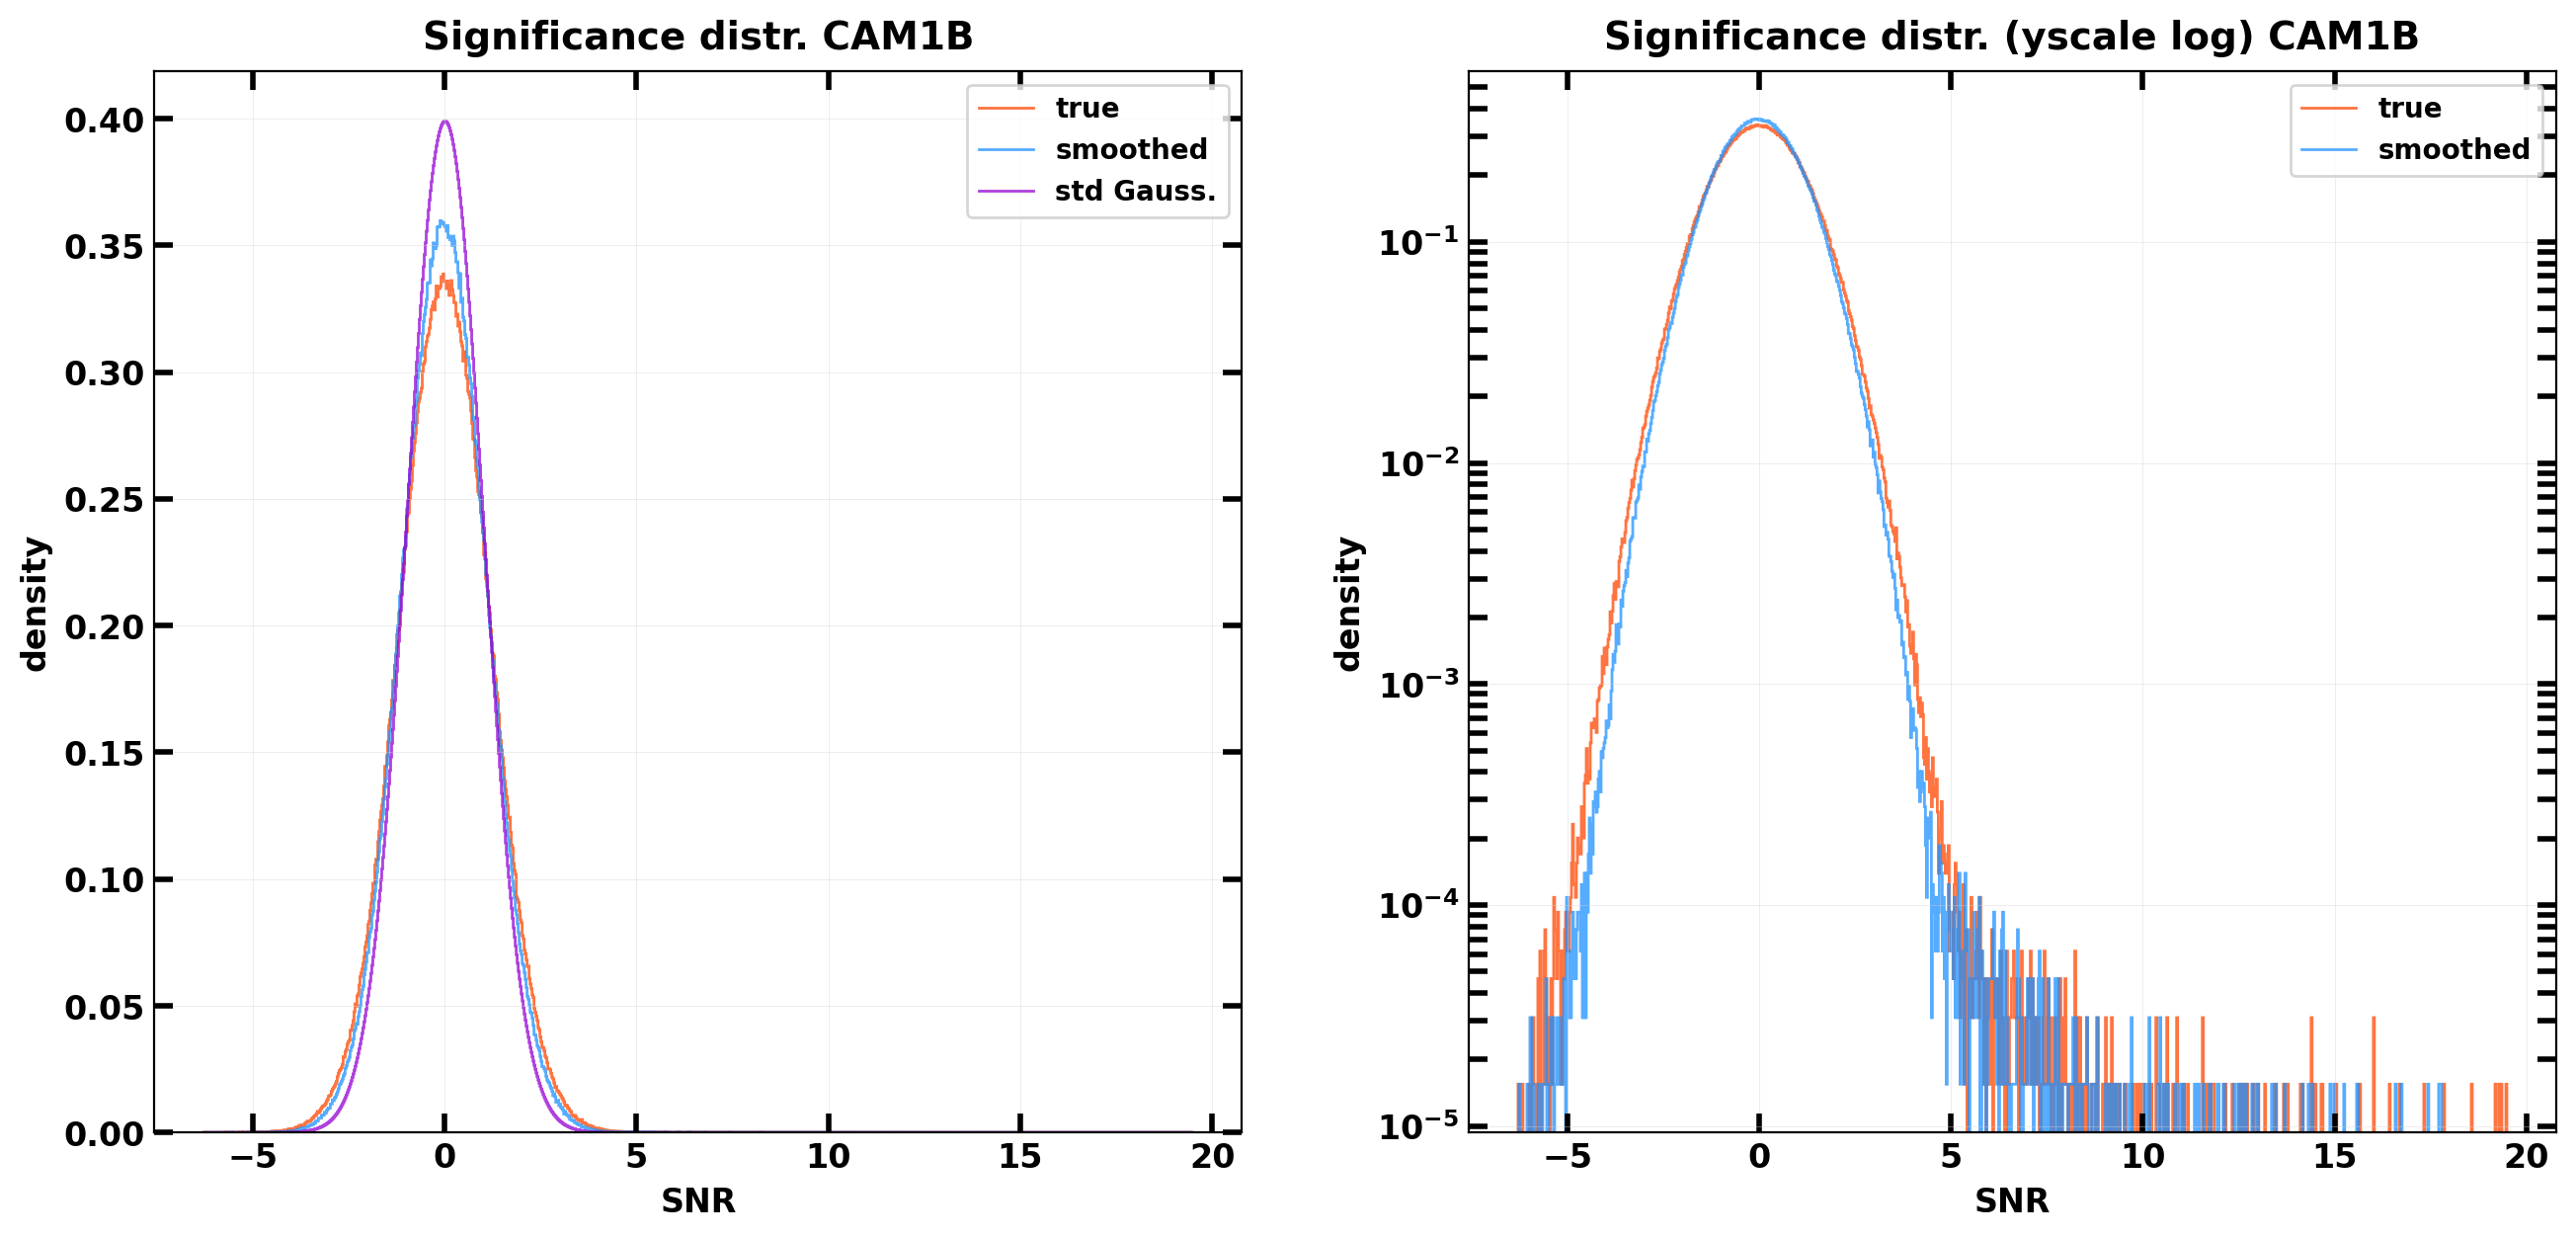

In [ ]:
smoothed_retrieved = retrieve_detector(
    candidates=smoothed_candidates,
    camera=wfm,
    vignetting=VIGNETTING,
    psfy=PSFY,
)
res_detector = smoothed - smoothed_retrieved
res_smoothed_sky = decode(wfm, res_detector)

res_skysnr_camB = ds.unframe(snratio(res_sky, varmap), ycut, xcut)
smoothed_skysnr_camB = ds.unframe(snratio(res_smoothed_sky, varmap), ycut, xcut)

hist_res_skysnr, bins = np.histogram(res_skysnr_camB, bins=num_bins, density=density)
hist_res_smoothed_skysnr, _ = np.histogram(smoothed_skysnr_camB, bins=bins, density=density)

gauss_distr = Gaussian(bins)[:-1]


x0, xN = None, None
bins_slice, hist_slice = config_snrlim(bins, x0, xN)

dmap1_snr = ds.map4plot(
    arrs=(hist_res_skysnr[hist_slice], hist_res_smoothed_skysnr[hist_slice], gauss_distr[hist_slice]),
    title=f'Significance distr. {ID_CAMERA_B.upper()}',
    xlabel='SNR',
    ylabel='density',
    labels=('true', 'smoothed', 'std Gauss.'),
    x=bins[bins_slice],
    style='stairs',
    color=('OrangeRed', 'Dodgerblue', 'DarkViolet'),
)
dmap2_snr = ds.map4plot(
    arrs=(hist_res_skysnr[hist_slice], hist_res_smoothed_skysnr[hist_slice]),
    title=f'Significance distr. (yscale log) {ID_CAMERA_B.upper()}',
    xlabel='SNR',
    ylabel='density',
    labels=('true', 'smoothed'),
    x=bins[bins_slice],
    style='stairs',
    color=('OrangeRed', 'Dodgerblue'),
    yscale='log',
)
ds.plot(
    dmaps=(dmap1_snr, dmap2_snr),
    ncols=2,
    save_to=(
        savefig_to(SAVE_TO, f'CFR_snr_distr_{ID_CAMERA_B.upper()}')
        if SAVE_THINGS else None
    ),
)

In [ ]:
from scipy.optimize import curve_fit

center_bins = 0.5 * (bins[:-1] + bins[1:])

popt_original, _ = curve_fit(Gaussian, xdata=center_bins, ydata=hist_res_skysnr, p0=[0, 1.0])
popt_smooothed, _ = curve_fit(Gaussian, xdata=center_bins, ydata=hist_res_smoothed_skysnr, p0=[0, 1.0])

print('Original (mu, sigma):', *popt_original)
print('Smoothed (mu, sigma):', *popt_smooothed)

Original (mu, sigma): 0.003435599012582135 1.1880298361006658
Smoothed (mu, sigma): -0.0071558745128633755 1.113896953088163


In [ ]:
# sources data + angular coords residues plot
data_DF(
    log=log_camB,
    catalogue=catalogueB,
    sdl=sdlB,
    camera=wfm,
)

Pixel angular resolution at upscaling (x, y): 2, 1
  - fine direction: 2.1163 arcmin
  - coarse direction: 8.4653 arcmin

# Source: scox1
Selected 1011426 ph out of 2493999 ph.
# Source: gx5-1
Selected 123995 ph out of 2493999 ph.
# Source: gx9+1
Selected 67866 ph out of 2493999 ph.
# Source: gx349+2
Selected 89256 ph out of 2493999 ph.
# Source: gx17+2
Selected 83298 ph out of 2493999 ph.
# Source: gx340+0
Selected 53612 ph out of 2493999 ph.
# Source: gx13+1
Selected 39428 ph out of 2493999 ph.
# Source: groj1655-40
Selected 45492 ph out of 2493999 ph.
# Source: x1820-303
Selected 37748 ph out of 2493999 ph.
# Source: gx3+1
Selected 39826 ph out of 2493999 ph.
# Source: cirx1
Selected 29194 ph out of 2493999 ph.
# Source: gx9+9
Selected 34817 ph out of 2493999 ph.
# Source: x1705-440
Selected 21973 ph out of 2493999 ph.
# Source: x1735-444
Selected 22928 ph out of 2493999 ph.
# Source: gx354-0
Selected 12759 ph out of 2493999 ph.
# Source: igrj17091-3624
Selected 9304 ph out of 24939

CAM1B                                                           
                ID         SNR DthetaX [arcmin] DthetaY [arcmin] Dfluence [%]
0            scox1  684.916254         0.002368         0.453553    -0.523637
1            gx5-1   78.222241         0.052970         1.343683     0.939894
2            gx9+1   43.806208         0.102397         0.441609     2.832446
3          gx349+2   40.805063         0.825864         2.814783   -18.601226
4           gx17+2   39.356184         0.102188         5.059612    -9.856274
5          gx340+0   30.504163         0.045271         0.134566     2.720333
6           gx13+1   25.587565         0.027980         0.349874     7.276264
7      groj1655-40   23.042792         0.063260         1.028373   -13.356783
8        x1820-303   22.455827         0.246139         2.663029    -7.386563
9            gx3+1   20.823892         0.216726         6.297012   -12.586972
10           cirx1   30.402587         0.146394         2.442809     6.256202
11           gx9+9   18.385940         0.286281         3.930248   -12.773409
12       x1705-440   15.449543         0.436582         8.714370    22.822556
13       x1735-444   12.891594         0.184078        15.096494    -6.864614
14         gx354-0    8.477024         0.286807         2.354976     8.791525
15  igrj17091-3624    7.287397         0.454126        39.467774    18.754953
16       x1636-536    8.581988         0.569200         8.219499    34.909647

In [ ]:
# sources data + angular coords residues plot
data_DF(
    log=log_camB_smoothed,
    catalogue=catalogueB,
    sdl=sdlB,
    camera=wfm,
)

Pixel angular resolution at upscaling (x, y): 2, 1
  - fine direction: 2.1163 arcmin
  - coarse direction: 8.4653 arcmin

# Source: scox1
Selected 1011426 ph out of 2493999 ph.
# Source: gx5-1
Selected 123995 ph out of 2493999 ph.
# Source: gx9+1
Selected 67866 ph out of 2493999 ph.
# Source: gx349+2
Selected 89256 ph out of 2493999 ph.
# Source: gx17+2
Selected 83298 ph out of 2493999 ph.
# Source: gx340+0
Selected 53612 ph out of 2493999 ph.
# Source: gx13+1
Selected 39428 ph out of 2493999 ph.
# Source: groj1655-40
Selected 45492 ph out of 2493999 ph.
# Source: x1820-303
Selected 37748 ph out of 2493999 ph.
# Source: gx3+1
Selected 39826 ph out of 2493999 ph.
# Source: cirx1
Selected 29194 ph out of 2493999 ph.
# Source: gx9+9
Selected 34817 ph out of 2493999 ph.
# Source: x1705-440
Selected 21973 ph out of 2493999 ph.
# Source: x1735-444
Selected 22928 ph out of 2493999 ph.
# Source: gx354-0
Selected 12759 ph out of 2493999 ph.
# Source: igrj17091-3624
Selected 9304 ph out of 24939

CAM1B                                                           
                ID         SNR DthetaX [arcmin] DthetaY [arcmin] Dfluence [%]
0            scox1  685.650389         0.002445         0.446421    -0.383998
1            gx5-1   77.715306         0.055068         1.419832     0.282621
2            gx9+1   44.233948         0.107518         0.389989     3.507359
3          gx349+2   41.404353         0.825864         2.814783   -17.405750
4           gx17+2   39.291269         0.108547         5.039703   -10.004958
5          gx340+0   30.621591         0.066553         1.654724     3.144044
6           gx13+1   25.854890         0.008541         2.065052    11.224006
7      groj1655-40   23.534629         0.073992         2.239613   -10.355635
8        x1820-303   21.319720         0.250664         3.426036   -14.217876
9            gx3+1   21.147280         0.173873         1.443802    -9.955634
10           cirx1   29.967371         0.116408         0.323931     3.023799
11           gx9+9   17.973035         0.245085         3.294910   -15.229656
12       x1705-440   15.037547         0.438171         6.723506    22.383004
13       x1735-444   12.211826         0.216847        12.253624   -13.706876
14         gx354-0    8.513705         0.298190         8.228302     9.002535
15  igrj17091-3624    7.636107         0.318307        32.361358    24.437499
16       x1636-536    8.410464         0.170295        15.363241    30.315556

<br>

<br>

## **IROS Reconstruction Efficiency**

In [21]:
import matplotlib.pyplot as plt

from darksun.show import DSPlot


def plotting(
    arr: NDArray,
    save_to: str | None,
    tags: tuple[Tag, ...] | None = None,
    show: bool = False,
    **kwargs: Any,
) -> None:
    dsp = DSPlot(1, 1)
    fig, ax = dsp.config_subplots(ptype='image')
    ax.imshow(arr, origin='lower', **kwargs)
    if tags is not None:
        tags_ = (tags,) if isinstance(tags, Tag) else tags
        for (name, y, x) in tags_:
            ax.scatter(
                x, y, s=20, facecolors='None', edgecolors='white',
                linewidths=0.4, alpha=0.9,
            )
            ax.text(
                x + 125, y, name, color='white', rotation=30,
                fontsize=7, fontweight='bold',
            )
    ax.axis('off')
    if save_to:
        fig.savefig(save_to, pad_inches=0)
    if show:
        plt.show()
    plt.close()

In [22]:
ANALYSIS_ID: str = "singleCAM_iros_upx2upy1_newOptimiser_smoothing"

PLT_SAVE_TO: str | Path = "/home/edoardo/Desktop"

**Camera A**

In [23]:
_, true_camA = ds.load_sky(f"{save_path}../{ANALYSIS_ID}/COMPOSED_sky_SIMUL_CAM1A_CAM1B_TEST_{ANALYSIS_ID}.fits")
_, iros_camA = ds.load_sky(f"{save_path}../{ANALYSIS_ID}/COMPOSED_OUTsky_IROS_CAM1A_CAM1B_TEST_{ANALYSIS_ID}.fits")

# Loading data...
# Loading completed!
# Loading data...
# Loading completed!


In [28]:
EXP = 0.8
VMAX = 20
CMAP = 'hot'

plotting(
    sqrt_display(true_camA, EXP),
    ds.savefig_to(PLT_SAVE_TO, 'GC_preiros_'),
    vmin=0, vmax=VMAX, cmap=CMAP,
)
plotting(
    sqrt_display(iros_camA, EXP),
    ds.savefig_to(PLT_SAVE_TO, 'GC_afteriros_'),
    vmin=0, vmax=VMAX, cmap=CMAP,
)

**Camera B**